In [26]:
# Fraud and Anomaly Detection with Deep Learning
# Jupyter Notebook Format

# ==============================
# 1. Setup and Imports
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, f1_score, precision_score, recall_score
)
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder


Dataset processing for IEEE-CIS data

In [27]:
# ==============================
# 2. Load and Merge IEEE-CIS Data
# ==============================
print("Defining function to load and merge IEEE-CIS datasets...")
def load_ieee_cis_data():
    # Load CSVs
    print("Loading IEEE-CIS datasets...")
    train_transaction = pd.read_csv("ieee-fraud-detection/train_transaction.csv")
    train_identity = pd.read_csv("ieee-fraud-detection/train_identity.csv")
    test_transaction = pd.read_csv("ieee-fraud-detection/test_transaction.csv")
    test_identity = pd.read_csv("ieee-fraud-detection/test_identity.csv")

    # Merging is necessary because the transaction data contains details like amounts and times,
    # while identity data includes device and browser info, all linked by TransactionID.
    # Combining them creates a comprehensive dataset for fraud detection features.

    # Merge train data
    train_data = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

    # Merge test data
    test_data = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

    print("Datasets loaded and merged successfully.")
    return train_data, test_data

Defining function to load and merge IEEE-CIS datasets...


## Dataset Feature Summary

- **TransactionDT**: Numerical timedelta in seconds from a reference point, spanning about 6 months.
- **card1-card6**: Categorical features encoding payment card details like type, category, issuing bank, and country.
- **C1-C14**: Numerical counts of associations (e.g., addresses linked to a card).
- **D1-D15**: Numerical timedeltas measuring days between transactions.
- **M1-M9**: Categorical match indicators (e.g., name/address matches).
- **V1-V339**: Numerical engineered features from Vesta, including rankings and entity relations.
- **addr1/addr2**: Categorical purchaser billing region and country.

These features help detect fraud through patterns in card usage, timing, matches, and geography, with C/D/V as numerical, M/card/addr as categorical, and TransactionDT as a time-based numerical field.

In [28]:
print("Defining function to perform feature engineering on the merged datasets...")
def perform_feature_engineering(train_data, test_data):
    # Feature engineering is crucial in fraud detection to extract meaningful patterns from raw data.
    # For example, creating features like transaction hour can capture time-based fraud patterns,
    # while ratios of transaction amounts to user averages can highlight anomalies in spending behavior.
    def feature_engineering(df):
        df["hour"] = (df["TransactionDT"] / 3600) % 24
        df["amount_to_mean_ratio"] = df["TransactionAmt"] / df.groupby("card1")["TransactionAmt"].transform("mean")
        df["transactions_per_user"] = df.groupby("card1")["TransactionAmt"].transform("count")
        return df

    print("Performing feature engineering...")
    train_data = feature_engineering(train_data)
    test_data = feature_engineering(test_data)

    # Inspect categorical features (from Kaggle dataset description)
    # Categorical in Transaction: ProductCD, card1-card6, addr1/addr2, P_emaildomain, R_emaildomain, M1-M9
    # Categorical in Identity: DeviceType, DeviceInfo, id_12-id_38
    transaction_categorical = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain'] + [f'M{i}' for i in range(1, 10)]
    identity_categorical = ['DeviceType', 'DeviceInfo'] + [f'id_{i}' for i in range(12, 39)]
    categorical_features = transaction_categorical + identity_categorical
    print("Categorical features (validated from dataset description):", categorical_features)

    return train_data, test_data, categorical_features


Defining function to perform feature engineering on the merged datasets...


In [29]:
print("Defining function to preprocess data (handle missing values, encode categoricals, and scale numerics)...")
# Evaluation function to compute the metrics based on the scores and true labels, and to find the best thresholds for F1 and cost.
def compute_threshold_metrics(scores, y_true, fn_cost=500, fp_cost=2):
    """Compute all threshold-related metrics once (precision, recall, F1, costs, best thresholds)."""
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    auprc = auc(recall, precision)
    roc = roc_auc_score(y_true, scores)
    
    # Compute F1 scores
    denom = precision[1:] + recall[1:]
    f1_scores = np.zeros_like(denom)
    mask = denom != 0
    f1_scores[mask] = 2 * precision[1:][mask] * recall[1:][mask] / denom[mask]
    
    # Compute costs
    num_pos = np.sum(y_true == 1)
    num_total = len(y_true)
    costs = []
    for p, r in zip(precision[1:], recall[1:]):
        tp = r * num_pos
        fp = tp * (1 / p - 1) if p > 0 else 0
        fn = num_pos - tp
        total_cost = fn * fn_cost + fp * fp_cost
        costs.append(total_cost / num_total)
    costs = np.array(costs)
    
    # Find best for F1 (max)
    best_f1_idx = np.argmax(f1_scores)
    best_f1_threshold = thresholds[best_f1_idx]
    best_f1 = f1_scores[best_f1_idx]
    best_f1_precision = precision[best_f1_idx + 1]
    best_f1_recall = recall[best_f1_idx + 1]
    
    # Find best for cost (min)
    best_cost_idx = np.argmin(costs)
    best_cost_threshold = thresholds[best_cost_idx]
    best_cost = costs[best_cost_idx]
    best_cost_preds = (scores >= best_cost_threshold).astype(int)
    best_cost_precision = precision_score(y_true, best_cost_preds)
    best_cost_recall = recall_score(y_true, best_cost_preds)
    best_cost_f1 = f1_score(y_true, best_cost_preds)
    
    return {
        'precision': precision, 'recall': recall, 'thresholds': thresholds,
        'f1_scores': f1_scores, 'costs': costs,
        'auprc': auprc, 'roc': roc,
        'best_f1_idx': best_f1_idx, 'best_f1_threshold': best_f1_threshold, 'best_f1': best_f1,
        'best_f1_precision': best_f1_precision, 'best_f1_recall': best_f1_recall,
        'best_cost_idx': best_cost_idx, 'best_cost_threshold': best_cost_threshold, 'best_cost': best_cost,
        'best_cost_precision': best_cost_precision, 'best_cost_recall': best_cost_recall, 'best_cost_f1': best_cost_f1
    }

def plot_threshold_analysis(scores, y_true, label, dataset_name, fn_cost=500, fp_cost=2, x_limits=None, plot_title=None, log_x=False):
    """Plot threshold analysis using precomputed metrics."""
    metrics = compute_threshold_metrics(scores, y_true, fn_cost, fp_cost)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # F1 on primary y-axis
    ax1.plot(metrics['thresholds'], metrics['f1_scores'], 'b-', label='F1 Score')
    ax1.axvline(x=metrics['best_f1_threshold'], color='blue', linestyle='--', label=f"Best F1 Threshold: {metrics['best_f1_threshold']:.4f}")
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('F1 Score', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    
    # Cost on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(metrics['thresholds'], metrics['costs'], 'r-', label='Expected Cost per Transaction')
    ax2.axvline(x=metrics['best_cost_threshold'], color='red', linestyle='--', label=f"Best Cost Threshold: {metrics['best_cost_threshold']:.4f}")
    ax2.set_ylabel('Expected Cost per Transaction', color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    # Title and legends
    if plot_title:
        plt.title(plot_title)
    else:
        plt.title(f'Threshold Analysis for {label} ({dataset_name})')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
    
    # Set x-axis limits if provided (useful for zooming in on relevant threshold ranges)
    if x_limits:
        ax1.set_xlim(x_limits)

    # Log scale for x-axis if requested (useful for cost when it varies widely)
    if log_x:
        ax1.set_xscale('log')

    # Set grid for better readability
    plt.grid(True)
    
    # Text for F1 best
    ax1.text(metrics['best_f1_threshold'] + 0.01, metrics['best_f1'] - 0.05, 
             f"F1: {metrics['best_f1']:.3f}\nPrec: {metrics['best_f1_precision']:.3f}\nRec: {metrics['best_f1_recall']:.3f}\nThresh: {metrics['best_f1_threshold']:.4f}", 
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
    
    # Text for cost best
    ax2.text(metrics['best_cost_threshold'] + 0.01, metrics['best_cost'] + 0.001, 
             f"Cost: ${metrics['best_cost']:.2f}\nPrec: {metrics['best_cost_precision']:.3f}\nRec: {metrics['best_cost_recall']:.3f}\nF1: {metrics['best_cost_f1']:.3f}\nThresh: {metrics['best_cost_threshold']:.4f}", 
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.8))
    
    # Text for cost at F1 best
    ax2.text(metrics['best_f1_threshold'] + 0.01, metrics['costs'][metrics['best_f1_idx']] + 0.001, 
             f"Cost at F1 Best:\n${metrics['costs'][metrics['best_f1_idx']]:.2f}", 
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))
    
    plt.show()

def evaluate_model(scores, y_true, label, dataset_name="Validation", fn_cost=500, fp_cost=2, plot_title=None, log_x=False):
    """Evaluate model using precomputed metrics."""
    metrics = compute_threshold_metrics(scores, y_true, fn_cost, fp_cost)
    
    print(f"{label} ({dataset_name})")
    print(f"AUPRC: {metrics['auprc']:.4f}")
    print(f"ROC AUC: {metrics['roc']:.4f}")
    
    print(f"Best F1 Threshold: {metrics['best_f1_threshold']:.4f}")
    print(f"At best F1 threshold - Precision: {metrics['best_f1_precision']:.4f}, Recall: {metrics['best_f1_recall']:.4f}, F1: {metrics['best_f1']:.4f}")
    print(f"Best Cost Threshold: {metrics['best_cost_threshold']:.4f}")
    print(f"At best cost threshold - Precision: {metrics['best_cost_precision']:.4f}, Recall: {metrics['best_cost_recall']:.4f}, F1: {metrics['best_cost_f1']:.4f}")

    # Plot threshold analysis (F1 and cost)
    plot_threshold_analysis(scores, y_true, label, dataset_name, fn_cost, fp_cost, plot_title=plot_title, log_x=log_x)



Defining function to preprocess data (handle missing values, encode categoricals, and scale numerics)...


In [71]:
print("Defining function to plot the precision-recall curve with AUPRC...")
def plot_precision_recall_curve(scores, y_true, label="Model", dataset_name="Validation", ax=None):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    pr_auc = auc(recall, precision)

    # F1 aligns with thresholded points, which correspond to precision[1:] and recall[1:].
    f1_scores = 2 * precision[1:] * recall[1:] / np.clip(precision[1:] + recall[1:], 1e-12, None)
    best_idx = np.argmax(f1_scores)
    best_precision = precision[best_idx + 1]
    best_recall = recall[best_idx + 1]
    best_f1 = f1_scores[best_idx]
    best_threshold = thresholds[best_idx]

    created_ax = ax is None
    if created_ax:
        fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(recall, precision, linewidth=2, label=f"{label} (AUPRC={pr_auc:.4f})")

    # Overlay the best-F1 operating point on the PR curve.
    ax.scatter(
        best_recall,
        best_precision,
        color="crimson",
        s=70,
        zorder=5,
        label=f"Best F1={best_f1:.4f}"
    )
    ax.annotate(
        f"Best F1 point\nP={best_precision:.3f}, R={best_recall:.3f}\nT={best_threshold:.4f}",
        xy=(best_recall, best_precision),
        xytext=(12, -10),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.9)
    )

    ax.set_title(f"Precision-Recall Curve: {label} ({dataset_name})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    if created_ax:
        plt.tight_layout()
        plt.show()

    return {
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
        "auprc": pr_auc,
        "best_f1": best_f1,
        "best_precision": best_precision,
        "best_recall": best_recall,
        "best_threshold": best_threshold
    }

Defining function to plot the precision-recall curve with AUPRC...


In [30]:
print("Defining function to clean and encode data (handle missing values, encode categoricals, and identify numeric features)...")
def clean_and_encode_data(train_data, test_data, categorical_features):
    # Prepare data with categorical encoding (modify in place to save memory)
    # Use the validated categorical feature list, and treat everything else numeric (excluding target and IDs)
    print("Cleaning and encoding data...")
    
    exclude_cols = set(categorical_features + ["isFraud", "TransactionID"])
    numeric_cols = [
        col for col in train_data.columns
        if col not in exclude_cols and pd.api.types.is_numeric_dtype(train_data[col])
    ]
    categorical_cols = categorical_features  # Use the validated list

    unavailable_numeric_cols = [col for col in numeric_cols if col not in test_data.columns]
    unavailable_categorical_cols = [col for col in categorical_cols if col not in test_data.columns]
    print(f"Unavailable numeric columns in test set: {unavailable_numeric_cols}")
    print(f"Unavailable categorical columns in test set: {unavailable_categorical_cols}")

    # Fill numeric NaNs in place
    for col in numeric_cols:
        if col in test_data.columns:
            train_data[col].fillna(0, inplace=True)
            test_data[col].fillna(0, inplace=True)

    # Encode categorical columns in place
    le = LabelEncoder()
    for col in categorical_cols:
        if col in test_data.columns:
            train_data[col].fillna('missing', inplace=True)
            test_data[col].fillna('missing', inplace=True)
            train_data[col] = le.fit_transform(train_data[col].astype(str))
            test_data[col] = le.fit_transform(test_data[col].astype(str))

    print("Data cleaning and encoding completed.")

    return train_data, test_data, numeric_cols, categorical_cols

Defining function to clean and encode data (handle missing values, encode categoricals, and identify numeric features)...


In [31]:
print("Defining function to prepare data for modeling (select features, split chronologically, and standardize numerics)...")
def prepare_ieee_cis_data(categorical_cols, numeric_cols, train_data, test_data):
    print("Loading and preparing data...")
    # Select features without copying
    available_cols = [col for col in numeric_cols + categorical_cols if col in test_data.columns]

    X = train_data[available_cols]
    y = train_data["isFraud"]
    train_data = None  # Free memory
    test_data = None  # Free memory

    # split data chronologically (80% train, 20% validation), this is important for time-series data to prevent data leakage from future to past
    split_index = int(0.8 * len(X))
    X_train, X_val = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_val = y.iloc[:split_index], y.iloc[split_index:]

    # Standardize numeric features in place
    print("Standardizing numeric features...")
    numeric_cols = [col for col in numeric_cols if col in available_cols]
    for col in numeric_cols:
        mean = X_train[col].mean()
        std = X_train[col].std()
        if std > 0:
            X_train_standardized = (X_train[col] - mean) / std
            X_val_standardized = (X_val[col] - mean) / std    
        X_train[col] = X_train_standardized
        X_val[col] = X_val_standardized

    X = None  # Free memory
    y = None  # Free memory

    print("Data preparation completed.")

    return X_train, y_train, X_val, y_val


Defining function to prepare data for modeling (select features, split chronologically, and standardize numerics)...


In [32]:
print("Defining function to prepare numeric features")
def prepare_numeric_features(X_train, X_val, numeric_cols):
    # As local outlier factor is sensitive to categorical data, we will only use numeric features for it.
    print("Preparing numeric features...")
    numeric_available = [col for col in numeric_cols if col in X_train.columns]
    X_train_numeric = X_train[numeric_available]
    X_val_numeric = X_val[numeric_available]

    print("Numeric features prepared.")
    return X_train_numeric, X_val_numeric


Defining function to prepare numeric features


Dataset processing for credit card fraud

In [33]:
def load_credit_card_fraud_data():
    print("Loading credit card fraud dataset...")
    # Use os.path.join for better cross-platform compatibility
    data = pd.read_csv(os.path.join("creditcardfraud", "creditcard.csv"))

    print("Split dataset into train and testing sets...")
    train_data = data.sample(frac=0.8, random_state=42)
    test_data = data.drop(train_data.index)

    print("Dataset loaded successfully.")
    return train_data, test_data

In [34]:
def process_credit_card_fraud_data(train_data, test_data):
    print("Processing credit card fraud data...")
    # The credit card fraud dataset is already preprocessed with PCA features and a 'Class' target. We just need to separate features and target.
    X_train = train_data.drop(columns=["Class", "Time"])
    y_train = train_data["Class"]
    X_test = test_data.drop(columns=["Class", "Time"])
    y_test = test_data["Class"]
    print("Credit card fraud data processed successfully.")
    return X_train, y_train, X_test, y_test

In [35]:
print("Defining function to train Isolation Forest model...")
def train_isolation_forest(X_train, X_val):
    # Isolation Forest
    print("Training Isolation Forest...")
    iso = IsolationForest(contamination=0.01, random_state=42)
    iso.fit(X_train)
    scores_iso_val = -iso.decision_function(X_val)
    print("Isolation Forest training completed.")
    print(f"scores_iso_val mean: {scores_iso_val.mean():.4f}")

    return scores_iso_val


Defining function to train Isolation Forest model...


In [36]:
print("Defining function to evaluate Isolation Forest model...")
def evaluate_isolation_forest(scores_iso_val, y_val, dataset="Validation"):
    print("Evaluating Isolation Forest...")
    evaluate_model(scores_iso_val, y_val, "Isolation Forest", dataset)
    print("Isolation Forest evaluation completed.")


Defining function to evaluate Isolation Forest model...


In [37]:
print("Defining function to train Local Outlier Factor model...")
def train_local_outlier_factor(X_train_numeric, X_val_numeric):
    # Local Outlier Factor (using only numerical features)
    print("Training Local Outlier Factor...")
    n_neighbors = min(20, len(X_train_numeric) - 1)  # Ensure n_neighbors is less than number of samples
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True)
    lof.fit(X_train_numeric)
    scores_lof_val = -lof.decision_function(X_val_numeric)
    print("Local Outlier Factor training completed.")
    print(f"scores_lof_val mean: {scores_lof_val.mean():.4f}")

    return scores_lof_val

Defining function to train Local Outlier Factor model...


In [55]:
print("Defining function to evaluate Local Outlier Factor model...")
def evaluate_local_outlier_factor(scores_lof_val, y_val, dataset="Validation"):
    print("Evaluating Local Outlier Factor...")
    evaluate_model(scores_lof_val, y_val, "Local Outlier Factor", dataset)
    print("Local Outlier Factor evaluation completed.")

Defining function to evaluate Local Outlier Factor model...


In [39]:
print("Defining function to prepare data for XGBoost...")
def prepare_data_for_xgboost(y_train):
    # Preparing data for Gradient Boosting (XGBoost)
    print("Preparing data for XGBoost...")

    # NOTE: Skipping one-hot encoding to avoid extremely high dimensionality / memory blow-up.
    # The code below shows how you could one-hot encode categorical columns if needed.
    # categorical_cols_available = [col for col in categorical_cols if col in X_train.columns]
    # X_train_xgb = pd.get_dummies(X_train, columns=categorical_cols_available, drop_first=True)
    # X_val_xgb = pd.get_dummies(X_val, columns=categorical_cols_available, drop_first=True)
    # X_val_xgb = X_val_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)

    # Calculate scale_pos_weight as ratio of negative to positive samples
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    scale_pos_weight = n_neg / n_pos

    print(f"Calculated scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")
    print("Data preparation for XGBoost completed.")
    return scale_pos_weight


Defining function to prepare data for XGBoost...


In [40]:
print("Defining function to train XGBoost model...")
def train_xgboost(X_train_xgb, y_train, X_val_xgb, scale_pos_weight):
    print("Training XGBoost...")
    xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="aucpr", random_state=42)
    xgb_model.fit(X_train_xgb, y_train)
    scores_xgb_val = xgb_model.predict_proba(X_val_xgb)[:,1]
    print("XGBoost training completed.")
    print(f"scores_xgb_val mean: {scores_xgb_val.mean():.4f}")

    return scores_xgb_val



Defining function to train XGBoost model...


In [41]:
print("Defining function to evaluate XGBoost model...")
def evaluate_xgboost(scores_xgb_val, y_val, dataset="Validation"):
    print("Evaluating XGBoost...")
    evaluate_model(scores_xgb_val, y_val, "XGBoost", dataset)
    print("XGBoost evaluation completed.")

Defining function to evaluate XGBoost model...


Comparing the baseline models, XGBoost achieved the best performance among the three. Not only it achieved the highest F1 score of 0.65, the cost curve rises slower and hits $7.87 when the F1 score is the highest. Isolation Forest costs ~$11 at F1 score of 0.244, while Local Outlier Factor costs ~$13 at F1 score of 0.112.

In [42]:
# ==============================
# 5. Deep Learning Approaches
# ==============================

# Function to plot loss against epochs for training and validation
def plot_loss(loss_all, val_loss_all, label):
    plt.figure(figsize=(10, 6))
    plt.plot(loss_all, label='Training Loss')
    plt.plot(val_loss_all, label='Validation Loss')
    plt.title(f'{label} - Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.legend()
    plt.grid()
    plt.show()



In [43]:
print("Defining function to prepare data for DNN...")
def prepare_data_for_dnn(X_train_dnn, y_train):
    # Prepare data for supervised deep learning (DNN Classifier)
    print("Preparing data for supervised deep learning...")

    # Further splitting the training data into a smaller training set and a validation set for the DNN, to monitor overfitting and perform early stopping.
    # Splitting it chronologically as well to prevent data leakage from future to past.
    print("Splitting data for DNN training and validation...")
    split_index_dnn = int(0.8 * len(X_train_dnn))
    X_train_dnn, X_val_dnn = X_train_dnn.iloc[:split_index_dnn], X_train_dnn.iloc[split_index_dnn:]
    y_train_dnn, y_val_dnn = y_train.iloc[:split_index_dnn], y_train.iloc[split_index_dnn:]
    input_dim = X_train_dnn.shape[1]


    # Calculate scale_pos_weight as ratio of negative to positive samples for handling class imbalance in the DNN training.
    n_neg = (y_train_dnn == 0).sum()
    n_pos = (y_train_dnn == 1).sum()
    scale_pos_weight = n_neg / n_pos

    print(f"Calculated scale_pos_weight for DNN: {scale_pos_weight:.2f}")
    print("Data preparation for DNN completed.")
    return X_train_dnn, y_train_dnn, X_val_dnn, y_val_dnn, input_dim, scale_pos_weight



Defining function to prepare data for DNN...


In [44]:


# ------------------------------
# 5.1 Autoencoder for Anomaly Detection
# ------------------------------

# Autoencoder architecture
# A smaller autoencoder architecture that reduces memory usage and training time.
class AutoencoderSmall(nn.Module):
    def __init__(self, input_dim):
        super(AutoencoderSmall, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
    

# Medium autoencoder architecture that balances complexity and resource usage.
class AutoencoderMedium(nn.Module):
    def __init__(self, input_dim):
        super(AutoencoderMedium, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
    

# Larger autoencoder architecture for potentially better performance at the cost of more resources.
class AutoencoderLarge(nn.Module):
    def __init__(self, input_dim):
        super(AutoencoderLarge, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))


In [45]:
def train_and_evaluate_autoencoders(X_train_dnn, y_train, X_val_dnn, X_val, y_val, dataset_name="IEEE-CIS"):
    print("Autoencoder architecture defined.")
    print("Preparing data for Autoencoder...")
    X_train_ae = X_train_dnn
    X_val_ae = X_val_dnn

    input_dim = X_train_ae.shape[1]

    # Train and evaluate each autoencoder architecture, while tracking the best model state for potential ensemble use later.
    autoencoder_list = [AutoencoderSmall, AutoencoderLarge]
    autoencoder_best_state_list = []  # To store the best model state across different architectures

    # Training methods: semi-supervised on normal data only, and supervsied on all data with class labels
    train_methods = ["semi-supervised", "supervised"]

    # Loop through each autoencoder architecture and train methods
    for train_method in train_methods:
        
        # Select training data based on the method
        if train_method == "semi-supervised":
            print("Training Autoencoders with semi-supervised method (normal data only)...")
            X_train_ae = X_train_dnn[y_train == 0]
        elif train_method == "supervised":
            print("Training Autoencoders with supervised method (all data with class labels)...")
            X_train_ae = X_train_dnn  # Use all data for supervised training

        for ae_class in autoencoder_list:
            # Train Autoencoder (semi-supervised on normal data only)
            print(f"Starting Autoencoder training for {ae_class.__name__} (dataset: {dataset_name}, method: {train_method})...")
            max_num_epochs = 500
            loss_stop_threshold = 1e-4
            min_loss = float('inf')
            delayed_stop_epochs = 20
            stop_counter = 0
            autoencoder_best_state = None
            prev_min_loss = float('inf')
            train_loss_all = []
            val_loss_all = []
            # max_stop_count = 2
            max_stop_count = max_num_epochs
            stop_count = 0
            batch_size = 64
            learning_rate = 1e-4  # it was 1e-3, but loss fluctuations were high, so reducing learning rate to stabilize training

            autoencoder = AutoencoderSmall(input_dim)
            optimizer = optim.Adam(autoencoder.parameters(), lr=learning_rate)
            criterion = nn.MSELoss()

            train_tensor = torch.tensor(X_train_ae.values, dtype=torch.float32)
            train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

            # Time the training process to monitor resource usage and ensure it completes within reasonable time limits.
            start_time = time.time()

            for epoch in range(max_num_epochs):
                for batch in train_loader:
                    inputs = batch[0]
                    outputs = autoencoder(inputs)
                    train_loss = criterion(outputs, inputs)
                    optimizer.zero_grad()
                    train_loss.backward()
                    optimizer.step()

                # Evaluate on validation set (normal data only)
                with torch.no_grad():
                    val_tensor = torch.tensor(X_val_ae.values, dtype=torch.float32)
                    val_outputs = autoencoder(val_tensor)
                    val_loss = criterion(val_outputs, val_tensor)

                # Print loss every epoch
                print(f"Epoch [{epoch+1}/{max_num_epochs}], Loss: {train_loss.item():.4f}")

                # Store loss for potential analysis
                train_loss_all.append(train_loss.item())
                val_loss_all.append(val_loss.item())

                # Early stopping if loss does not improve significantly
                if abs(min_loss - val_loss.item()) < loss_stop_threshold:
                    print("Early stopping triggered due to minimal improvement.")
                    break
                # Track minimum loss for potential early stopping
                # Stop if loss has not improved for a certain number of epochs
                elif val_loss.item() < min_loss:
                    min_loss = val_loss.item()
                    stop_counter = 0
                    autoencoder_best_state = autoencoder.state_dict()  # Save best model state
                else:
                    stop_counter += 1
                    print(f"No improvement in loss. Stop counter: {stop_counter}/{delayed_stop_epochs}")
                    if stop_counter >= delayed_stop_epochs:
                        print("Early stopping triggered due to lack of improvement.")
                        break

                # Stop according to max_stop_count
                if stop_count == max_stop_count:
                    break
                else:
                    stop_count += 1

            end_time = time.time()
            print(f"Autoencoder training time for {ae_class.__name__} (dataset: {dataset_name}, method: {train_method}): {end_time - start_time:.2f} seconds")

            autoencoder.load_state_dict(autoencoder_best_state)  # Load best model state
            print(f"Autoencoder training completed for {ae_class.__name__} (dataset: {dataset_name}, method: {train_method}).")

            autoencoder_best_state_list.append(autoencoder.state_dict())  # Accumulate best states for potential ensemble (not implemented here)

            # Plot loss curves for the Autoencoder to visualize training progress and potential overfitting.
            plot_loss(train_loss_all, val_loss_all, f"Autoencoder {ae_class.__name__} (dataset: {dataset_name}, method: {train_method})")

            # Evaluate on test set
            print(f"Evaluating Autoencoder {ae_class.__name__} on test set...")
            with torch.no_grad():
                test_tensor = torch.tensor(X_val.values, dtype=torch.float32)
                test_outputs = autoencoder(test_tensor)
                test_loss = torch.mean((test_outputs - test_tensor) ** 2, dim=1).numpy()
                print(f"Autoencoder {ae_class.__name__} test loss computed.")
                print(f"test_loss mean: {test_loss.mean():.4f}")
                print(f"test_loss max: {test_loss.max():.4f}")
                print(f"test_loss min: {test_loss.min():.4f}")
                print(f"test_loss std: {test_loss.std():.4f}")

            # Evaluate model with the title reflecting the Autoencoder architecture and training method, and log scale for x-axis to better visualize cost when it varies widely across thresholds.
            evaluate_model(test_loss, y_val, f"Autoencoder {ae_class.__name__} ({train_method})", dataset_name, log_x=True)

            # Zoom in on threshold analysis for Autoencoder to better visualize the relevant range of thresholds.
            # x_limits = (0, np.percentile(test_loss, 99))  # Focus on the range where most data points lie
            # plot_threshold_analysis(test_loss, y_val, f"Autoencoder {ae_class.__name__} ({train_method})", "Test", x_limits=x_limits, plot_title=f"Zoomed Threshold Analysis for Autoencoder {ae_class.__name__} ({train_method})", log_x=True)

    return autoencoder_best_state_list  # Return the list of best model states for potential ensemble use later (not implemented here)


In [46]:
# ------------------------------
# 5.2 Supervised Deep Learning (e.g., DNN Classifier)
# ------------------------------

# Suervised deep learning architecture
# An MLP (Multi-Layer Perceptron) as a simple network for starightforward supervised classification.
class DNNClassifierMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DNNClassifierMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
# A Resnet-like architecture for tabular data, which can capture more complex patterns.
class DNNClassifierResNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DNNClassifierResNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.relu(self.fc2(out) + out)  # Residual connection
        out = self.fc3(out)
        return out
    
# A LSTM (Long Short-Term Memory) architecture for sequential modeling, which can capture temporal patterns in transaction data.
class DNNClassifierLSTM(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DNNClassifierLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, 128, batch_first=True)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x.unsqueeze(1))  # Add sequence dimension
        lstm_out = lstm_out[:, -1, :]  # Take the output of the last time step
        out = self.fc(lstm_out)
        return out
    

In [47]:
# Train and evaluate each supervised deep learning architecture, while tracking the best model state for potential ensemble use later.
def train_and_evaluate_dnn(input_dim, num_classes, X_train_dnn, y_train_dnn, X_val_dnn, y_val_dnn, X_test_dnn, y_test_dnn, scale_pos_weight, dataset_name="IEEE-CIS"):
    dnn_list = [DNNClassifierMLP, DNNClassifierResNet]
    # dnn_list = [DNNClassifierMLP, DNNClassifierResNet, DNNClassifierLSTM]
    dnn_best_state_list = []  # To store the best model state across different architectures


    for dnn_class in dnn_list:
        max_num_epochs = 500
        loss_delta_threshold = 1e-4
        best_val_loss = float('inf')
        delayed_stop_epochs = 20
        stop_counter = 0
        dnn_best_state = None
        train_loss_all = []
        val_loss_all = []
        # max_stop_count = 2
        max_stop_count = max_num_epochs
        stop_count = 0
        batch_size = 64
        learning_rate = 1e-4  # it was 1e-3, but loss fluctuations were quite high, so reducing learning rate to stabilize training

        dnn_model = dnn_class(input_dim, num_classes)
        optimizer = optim.Adam(dnn_model.parameters(), lr=learning_rate)

        # Create a criterion with focal loss to handle class imbalance, which can be more effective than standard cross-entropy in cases of severe imbalance.
        class_weights = torch.tensor([1.0, scale_pos_weight], dtype=torch.float32)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        train_tensor = torch.tensor(X_train_dnn.values, dtype=torch.float32)
        train_labels = torch.tensor(y_train_dnn.values, dtype=torch.long)
        train_loader = DataLoader(TensorDataset(train_tensor, train_labels), batch_size=batch_size, shuffle=True)

        # Train DNN Classifier
        print(f"Starting DNN training for {dnn_class.__name__} (dataset: {dataset_name})...")

        # Time the training process to monitor resource usage and ensure it completes within reasonable time limits.
        start_time = time.time()
        for epoch in range(max_num_epochs):
            dnn_model.train()
            for batch in train_loader:
                inputs, labels = batch
                outputs = dnn_model(inputs)
                train_loss = criterion(outputs, labels)
                optimizer.zero_grad()
                train_loss.backward()
                optimizer.step()

            # Evaluate on validation set every epoch
            dnn_model.eval()
            with torch.no_grad():
                val_tensor = torch.tensor(X_val_dnn.values, dtype=torch.float32)
                val_labels = torch.tensor(y_val_dnn.values, dtype=torch.long)
                val_outputs = dnn_model(val_tensor)
                val_loss = criterion(val_outputs, val_labels).item()
            
            print(f"Epoch [{epoch+1}/{max_num_epochs}], Validation Loss: {val_loss:.4f}")

            # Store loss for potential analysis
            train_loss_all.append(train_loss.item())
            val_loss_all.append(val_loss)

            # Early stop if delta loss does not improve significantly compared to the best validation loss, which can help prevent overfitting and save training time.
            loss_delta = abs(best_val_loss - val_loss)
            if loss_delta < loss_delta_threshold:
                print("Early stopping triggered due to minimal improvement in validation loss.")
                break
            # Current validation loss is better than the best validation loss, so update the best validation loss and reset the stop counter. This helps to track the best model state for potential early stopping.
            elif val_loss < best_val_loss:
                best_val_loss = val_loss
                stop_counter = 0
                dnn_best_state = dnn_model.state_dict()  # Save best model state
            # Validation loss did not improve, so increment the stop counter and check if it has reached the threshold for early stopping. This helps to prevent overfitting by stopping training when the model is no longer improving on the validation set.
            else:
                stop_counter += 1
                print(f"No improvement in validation loss. Stop counter: {stop_counter}/{delayed_stop_epochs}")
                if stop_counter >= delayed_stop_epochs:
                    print("Early stopping triggered due to lack of improvement.")
                    break

            # Stop according to max_stop_count
            if stop_count == max_stop_count:
                break
            else:
                stop_count += 1

        end_time = time.time()
        print(f"DNN training time for {dnn_class.__name__} (dataset: {dataset_name}): {end_time - start_time:.2f} seconds")

        dnn_model.load_state_dict(dnn_best_state)  # Load best model state
        dnn_best_state_list.append(dnn_model.state_dict())  # Accumulate best states for potential ensemble (not implemented here)
        print(f"DNN training completed for {dnn_class.__name__} (dataset: {dataset_name}).")

        # Plot loss curves for the DNN to visualize training progress and potential overfitting.
        plot_loss(train_loss_all, val_loss_all, f"DNN {dnn_class.__name__} (dataset: {dataset_name})")

        # Evaluate on validation set
        print(f"Evaluating DNN {dnn_class.__name__} on validation set...")
        dnn_model.eval()
        with torch.no_grad():
            val_tensor = torch.tensor(X_test_dnn.values, dtype=torch.float32)
            val_labels = torch.tensor(y_test_dnn.values, dtype=torch.long)
            val_outputs = dnn_model(val_tensor)
            val_loss = criterion(val_outputs, val_labels).item()
        print(f"DNN {dnn_class.__name__} validation loss: {val_loss:.4f}")
        val_probs = torch.softmax(val_outputs, dim=1)[:, 1].numpy()  # Get probabilities for the positive class
        evaluate_model(val_probs, y_test_dnn, f"DNN {dnn_class.__name__}", dataset_name)

    return dnn_best_state_list  # Return the list of best model states for potential ensemble use later (not implemented here)



Error Analysis Functions

In [48]:
print("Defining function to plot threshold analysis for the best model, which can help visualize how different threshold choices affect the trade-off between true positives and false positives, and identify optimal thresholds for deployment based on the specific requirements of the application.")
# Define a function to plot false positive examples for the best model, which can help visualize what kind of transactions are being misclassified as fraudulent and provide insights into potential areas for improvement in the model.
def plot_false_positives(model, X_val, y_val, model_name, dataset_name="Dataset", num_examples=10):
    print(f"Plotting false positive examples for {model_name} on {dataset_name}...")
    if model_name == "Isolation Forest":
        scores = model
        threshold = np.percentile(scores, 99)  # Example threshold for false positives
        false_positives = (scores > threshold) & (y_val == 0)
    elif model_name == "Local Outlier Factor":
        scores = model
        threshold = np.percentile(scores, 99)  # Example threshold for false positives
        false_positives = (scores > threshold) & (y_val == 0)
    elif model_name == "XGBoost":
        scores = model
        threshold = 0.5  # Example threshold for classification
        false_positives = (scores > threshold) & (y_val == 0)
    else:
        print("False positive plotting not implemented for this model.")
        return

    X_false_positives = X_val[false_positives]
    y_false_positives = y_val[false_positives]

    # Randomly select a few false positive examples to plot, which can help visualize the distribution of feature values for these misclassified transactions and identify potential patterns.
    if len(X_false_positives) > num_examples:
        X_false_positives = X_false_positives.sample(num_examples, random_state=42)
        y_false_positives = y_false_positives.loc[X_false_positives.index]
        
    # Search for N features that have the highest variance among the false positives to visualize in the box plot, which can help identify which features are most influential in the misclassification of these transactions.
    num_features = 5
    feature_variances = X_false_positives.var().sort_values(ascending=False)
    top_features = feature_variances.head(num_features).index
    X_false_positives = X_false_positives[top_features]

    # Plot box plots for the false positive examples to visualize the distribution of feature values for these misclassified transactions, which can provide insights into potential patterns or characteristics that are leading to false positives.
    plt.figure(figsize=(12, 6))
    plt.boxplot(X_false_positives.values, labels=X_false_positives.columns)
    plt.title(f"{num_features} Features that have the highest variance for False Positive Examples (N={num_examples}) {model_name} on {dataset_name}")
    plt.xlabel("Feature Index")
    plt.ylabel("Feature Value")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()
    


Defining function to plot threshold analysis for the best model, which can help visualize how different threshold choices affect the trade-off between true positives and false positives, and identify optimal thresholds for deployment based on the specific requirements of the application.


In [49]:
# Define a function to plot false negative examples for the best model, which can help visualize what kind of fraudulent transactions are being misclassified as non-fraudulent and provide insights into potential areas for improvement in the model.
def plot_false_negatives(model, X_val, y_val, model_name, dataset_name="Dataset", num_examples=10):
    print(f"Plotting false negative examples for {model_name} on {dataset_name}...")
    if model_name == "Isolation Forest":
        scores = model
        threshold = np.percentile(scores, 1)  # Example threshold for false negatives
        false_negatives = (scores < threshold) & (y_val == 1)
    elif model_name == "Local Outlier Factor":
        scores = model
        threshold = np.percentile(scores, 1)  # Example threshold for false negatives
        false_negatives = (scores < threshold) & (y_val == 1)
    elif model_name == "XGBoost":
        scores = model
        threshold = 0.5  # Example threshold for classification
        false_negatives = (scores < threshold) & (y_val == 1)
    else:
        print("False negative plotting not implemented for this model.")
        return

    X_false_negatives = X_val[false_negatives]
    y_false_negatives = y_val[false_negatives]

    # Randomly select a few false negative examples to plot, which can help visualize the distribution of feature values for these misclassified transactions and identify potential patterns.
    if len(X_false_negatives) > num_examples:
        X_false_negatives = X_false_negatives.sample(num_examples, random_state=42)
        y_false_negatives = y_false_negatives.loc[X_false_negatives.index]

    # Search for N features that have the highest variance among the false negatives to visualize in the box plot, which can help identify which features are most influential in the misclassification of these transactions.
    num_features = 5
    feature_variances = X_false_negatives.var().sort_values(ascending=False)
    top_features = feature_variances.head(num_features).index
    X_false_negatives = X_false_negatives[top_features]

    # Plot box plots for the false negative examples to visualize the distribution of feature values for these misclassified transactions, which can provide insights into potential patterns or characteristics that are leading to false negatives.
    plt.figure(figsize=(12, 6))
    plt.boxplot(X_false_negatives.values, labels=X_false_negatives.columns)
    plt.title(f"{num_features} Features that have the highest variance for False Negative Examples (N={num_examples}) {model_name} on {dataset_name}")
    plt.xlabel("Feature Index")
    plt.ylabel("Feature Value")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

In [50]:
# ==============================
# Main execution flow
# ==============================

# IEEE-CIS Fraud Detection dataset
# Load and prepare data
train_data, test_data = load_ieee_cis_data()

# Perform feature engineering and data cleaning/encoding, while tracking the categorical features for proper handling in subsequent steps.
train_data, test_data, categorical_features = perform_feature_engineering(train_data, test_data)

# Clean and encode data, while tracking numeric and categorical columns for proper handling in subsequent steps.
train_data, test_data, numeric_cols, categorical_cols = clean_and_encode_data(train_data, test_data, categorical_features)  

# Prepare data for modeling, while ensuring that we only select features that are available in the test set to prevent issues during evaluation.
X_train, y_train, X_val, y_val = prepare_ieee_cis_data(categorical_cols, numeric_cols, train_data, test_data)

# Free memory by deleting the original DataFrames that are no longer needed after preparing the training and validation sets.
train_data = None  # Free memory
test_data = None  # Free memory

# Prepare numeric features for features that do not handle categorical data well (e.g., Local Outlier Factor), while ensuring we only select numeric features that are available in the training and validation sets.
X_train_numeric, X_val_numeric = prepare_numeric_features(X_train, X_val, numeric_cols)


# Credit Card Fraud dataset
# Load credit card fraud data
train_data_credit_card_fraud, test_data_crdit_card_fraud = load_credit_card_fraud_data()

# Process credit card fraud data
X_train_ccf, y_train_ccf, X_test_ccf, y_test_ccf = process_credit_card_fraud_data(train_data_credit_card_fraud, test_data_crdit_card_fraud)


Loading IEEE-CIS datasets...
Datasets loaded and merged successfully.
Performing feature engineering...
Categorical features (validated from dataset description): ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
Cleaning and encoding data...
Unavailable numeric columns in test set: ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11']
Unavailable categorical columns in test set: ['id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_

C:\Users\Admin\AppData\Local\Temp\ipykernel_33236\3240019260.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data[col].fillna(0, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_33236\3240019260.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

Data cleaning and encoding completed.
Loading and preparing data...
Standardizing numeric features...


C:\Users\Admin\AppData\Local\Temp\ipykernel_33236\4054746277.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train_standardized
C:\Users\Admin\AppData\Local\Temp\ipykernel_33236\4054746277.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col] = X_val_standardized


Data preparation completed.
Preparing numeric features...
Numeric features prepared.
Loading credit card fraud dataset...
Split dataset into train and testing sets...
Dataset loaded successfully.
Processing credit card fraud data...
Credit card fraud data processed successfully.


In [51]:
# Train and evaluate Isolation Forest, while tracking the scores for potential ensemble use later.

# IEEE CIS dataset
print("Training and evaluating Isolation Forest on IEEE CIS dataset...")
scores_iso_val = train_isolation_forest(X_train, X_val)

# Credit card fraud dataset
print("Training and evaluating Isolation Forest on Credit Card Fraud dataset...")
scores_iso_val_ccf = train_isolation_forest(X_train_ccf, X_test_ccf)


Training and evaluating Isolation Forest on IEEE CIS dataset...
Training Isolation Forest...
Isolation Forest training completed.
scores_iso_val mean: -0.1950
Training and evaluating Isolation Forest on Credit Card Fraud dataset...
Training Isolation Forest...
Isolation Forest training completed.
scores_iso_val mean: -0.1899


Evaluating Isolation Forest...
Isolation Forest (IEEE-CIS)
AUPRC: 0.1168
ROC AUC: 0.7739
Best F1 Threshold: -0.1074
At best F1 threshold - Precision: 0.1712, Recall: 0.3772, F1: 0.2355
Best Cost Threshold: -0.2496
At best cost threshold - Precision: 0.0344, Recall: 1.0000, F1: 0.0666


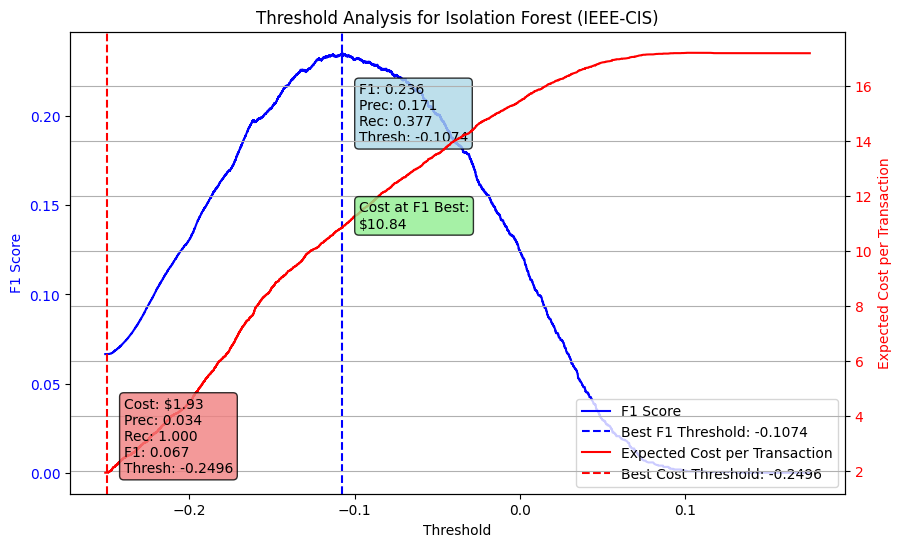

Isolation Forest evaluation completed.
Evaluating Isolation Forest...
Isolation Forest (Credit Card Fraud)
AUPRC: 0.1472
ROC AUC: 0.9540
Best F1 Threshold: 0.0797
At best F1 threshold - Precision: 0.2650, Recall: 0.2952, F1: 0.2793
Best Cost Threshold: -0.0839
At best cost threshold - Precision: 0.0439, Recall: 0.8571, F1: 0.0836


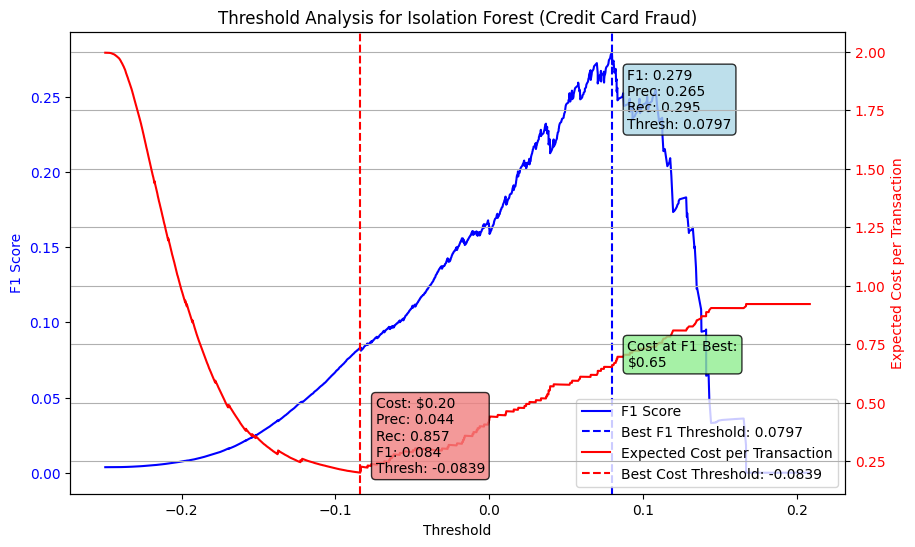

Isolation Forest evaluation completed.


In [29]:
# Evaluate Isolation Forest with the title reflecting the model and dataset, and log scale for x-axis to better visualize cost when it varies widely across thresholds.

# IEEE CIS dataset
evaluate_isolation_forest(scores_iso_val, y_val, dataset="IEEE-CIS")

# Credit card fraud dataset
evaluate_isolation_forest(scores_iso_val_ccf, y_test_ccf, dataset="Credit Card Fraud")

In [52]:
# Train and evaluate Local Outlier Factor, while tracking the scores for potential ensemble use later.
# IEEE CIS dataset
scores_lof_val = train_local_outlier_factor(X_train_numeric, X_val_numeric)

# Credit card fraud dataset
scores_lof_val_ccf = train_local_outlier_factor(X_train_ccf, X_test_ccf)

Training Local Outlier Factor...


c:\Users\Admin\Documents\Projects\Kai Ling master\DSS5104 Assignment\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Local Outlier Factor training completed.
scores_lof_val mean: 0.2699
Training Local Outlier Factor...


c:\Users\Admin\Documents\Projects\Kai Ling master\DSS5104 Assignment\.venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Local Outlier Factor training completed.
scores_lof_val mean: 4123293.4649


Evaluating Local Outlier Factor...
Local Outlier Factor (IEEE-CIS)
AUPRC: 0.0352
ROC AUC: 0.5233
Best F1 Threshold: -0.1541
At best F1 threshold - Precision: 0.0376, Recall: 0.6405, F1: 0.0710
Best Cost Threshold: -0.5425
At best cost threshold - Precision: 0.0344, Recall: 1.0000, F1: 0.0665


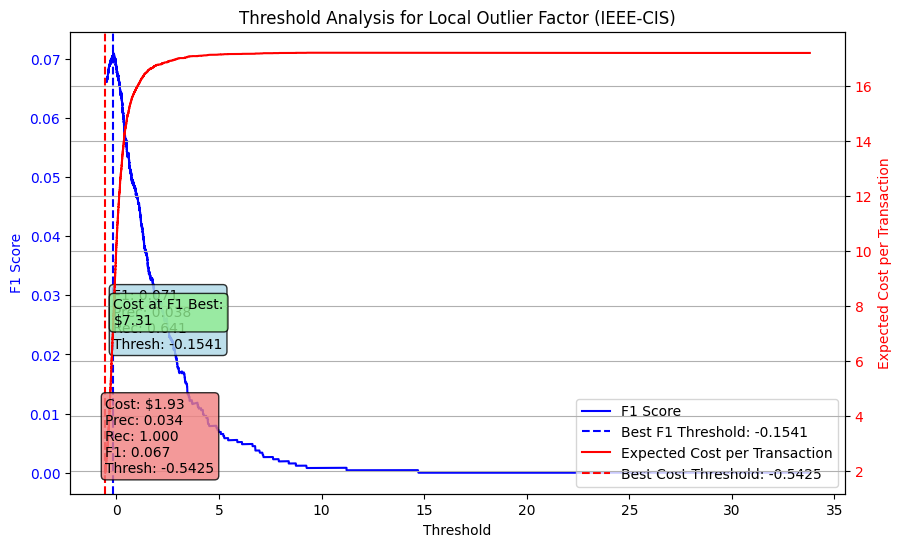

Local Outlier Factor evaluation completed.
Evaluating Local Outlier Factor...
Local Outlier Factor (Credit Card Fraud)
AUPRC: 0.0156
ROC AUC: 0.6526
Best F1 Threshold: 1.3210
At best F1 threshold - Precision: 0.0739, Recall: 0.1429, F1: 0.0974
Best Cost Threshold: 0.2407
At best cost threshold - Precision: 0.0287, Recall: 0.2952, F1: 0.0523


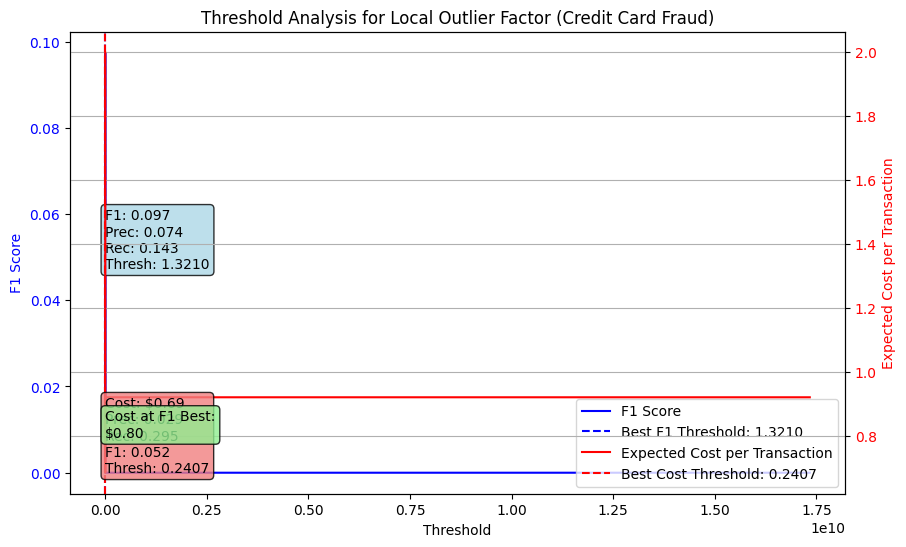

Local Outlier Factor evaluation completed.


In [56]:
# Evaluate Local Outlier Factor with the title reflecting the model and dataset, and log scale for x-axis to better visualize cost when it varies widely across thresholds.
# IEEE CIS dataset
evaluate_local_outlier_factor(scores_lof_val, y_val, dataset="IEEE-CIS")

# Credit card fraud dataset
evaluate_local_outlier_factor(scores_lof_val_ccf, y_test_ccf, dataset="Credit Card Fraud")

In [62]:
# Prepare data for XGBoost, while calculating the scale_pos_weight to handle class imbalance effectively during training.

# IEEE CIS dataset
print("Preparing data for XGBoost on IEEE CIS dataset...")
scale_pos_weight = prepare_data_for_xgboost(y_train)

# Train and evaluate XGBoost, while tracking the scores for potential ensemble use later.
scores_xgb_val = train_xgboost(X_train, y_train, X_val, scale_pos_weight)

# Credit card fraud dataset
print("Preparing data for XGBoost on Credit Card Fraud dataset...")
scale_pos_weight_ccf = prepare_data_for_xgboost(y_train_ccf)
scores_xgb_val_ccf = train_xgboost(X_train_ccf, y_train_ccf, X_test_ccf, scale_pos_weight_ccf)

Preparing data for XGBoost on IEEE CIS dataset...
Preparing data for XGBoost...
Calculated scale_pos_weight for XGBoost: 27.46
Data preparation for XGBoost completed.
Training XGBoost...
XGBoost training completed.
scores_xgb_val mean: 0.1838
Preparing data for XGBoost on Credit Card Fraud dataset...
Preparing data for XGBoost...
Calculated scale_pos_weight for XGBoost: 587.75
Data preparation for XGBoost completed.
Training XGBoost...
XGBoost training completed.
scores_xgb_val mean: 0.0018


Evaluating XGBoost on IEEE CIS dataset...
Evaluating XGBoost...
XGBoost (IEEE-CIS)
AUPRC: 0.5156
ROC AUC: 0.9062
Best F1 Threshold: 0.8512
At best F1 threshold - Precision: 0.5906, Recall: 0.4355, F1: 0.5013
Best Cost Threshold: 0.0398
At best cost threshold - Precision: 0.0466, Recall: 0.9882, F1: 0.0890


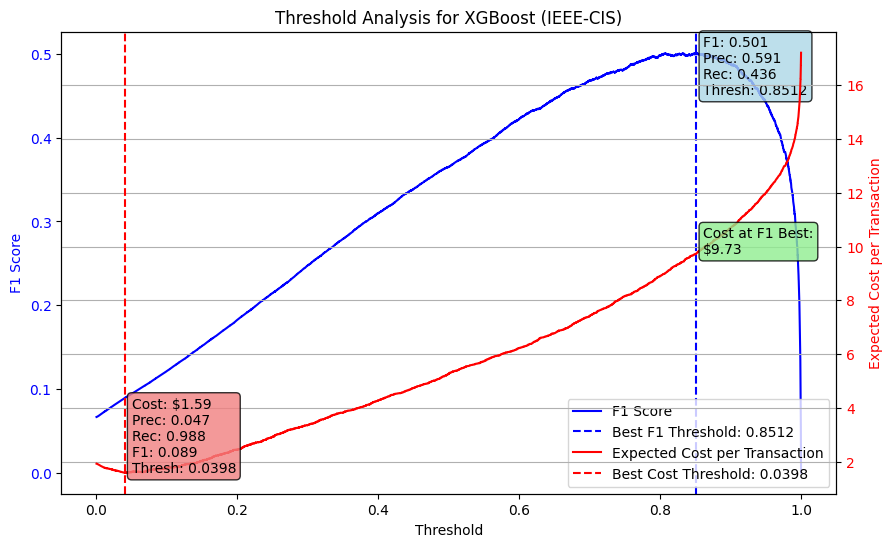

XGBoost evaluation completed.
Evaluating XGBoost on Credit Card Fraud dataset...
Evaluating XGBoost...
XGBoost (Credit-Card-Fraud)
AUPRC: 0.9011
ROC AUC: 0.9751
Best F1 Threshold: 0.9985
At best F1 threshold - Precision: 1.0000, Recall: 0.8190, F1: 0.9005
Best Cost Threshold: 0.0016
At best cost threshold - Precision: 0.3194, Recall: 0.9429, F1: 0.4771


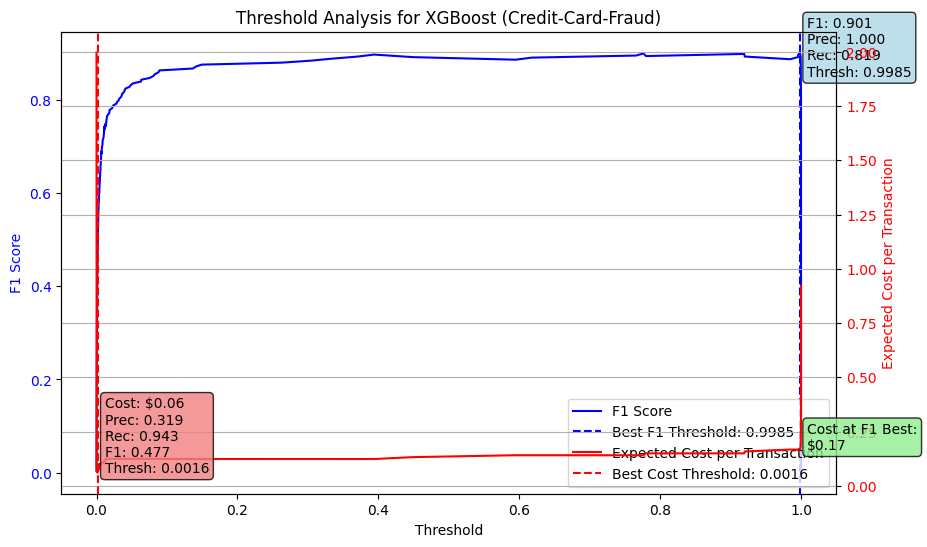

XGBoost evaluation completed.


In [33]:
# Evaluate XGBoost with the title reflecting the model and dataset, and log scale for x-axis to better visualize cost when it varies widely across thresholds.

# IEEE CIS dataset
print("Evaluating XGBoost on IEEE CIS dataset...")
evaluate_xgboost(scores_xgb_val, y_val, dataset="IEEE-CIS")

# Credit card fraud dataset
print("Evaluating XGBoost on Credit Card Fraud dataset...")
evaluate_xgboost(scores_xgb_val_ccf, y_test_ccf, dataset="Credit-Card-Fraud")

Deep Learning Models

In [27]:
# Prepare data for DNN, while further splitting the training data into a smaller training set and a validation set for the DNN, to monitor overfitting and perform early stopping. Also calculate the scale_pos_weight to handle class imbalance effectively during DNN training.

# IEEE CIS dataset
X_train_dnn, y_train_dnn, X_val_dnn, y_val_dnn, input_dim, scale_pos_weight = prepare_data_for_dnn(X_train, y_train)

# Credit card fraud dataset
X_train_dnn_ccf, y_train_dnn_ccf, X_val_dnn_ccf, y_val_dnn_ccf, input_dim_ccf, scale_pos_weight_ccf = prepare_data_for_dnn(X_train_ccf, y_train_ccf)



Preparing data for supervised deep learning...
Splitting data for DNN training and validation...
Calculated scale_pos_weight for DNN: 28.31
Data preparation for DNN completed.
Preparing data for supervised deep learning...
Splitting data for DNN training and validation...
Calculated scale_pos_weight for DNN: 598.59
Data preparation for DNN completed.


Autoencoder architecture defined.
Preparing data for Autoencoder...
Training Autoencoders with semi-supervised method (normal data only)...
Starting Autoencoder training for AutoencoderSmall (dataset: IEEE-CIS, method: semi-supervised)...
Epoch [1/500], Loss: 26.0147
Epoch [2/500], Loss: 6.1889
Epoch [3/500], Loss: 2.5619
Epoch [4/500], Loss: 2.2509
Epoch [5/500], Loss: 2.8832
Epoch [6/500], Loss: 2.0793
Epoch [7/500], Loss: 1.9249
No improvement in loss. Stop counter: 1/20
Epoch [8/500], Loss: 1.5733
Epoch [9/500], Loss: 1.3034
Epoch [10/500], Loss: 1.2237
Epoch [11/500], Loss: 1.2266
Epoch [12/500], Loss: 1.2841
No improvement in loss. Stop counter: 1/20
Epoch [13/500], Loss: 1.5082
Epoch [14/500], Loss: 1.1575
No improvement in loss. Stop counter: 1/20
Epoch [15/500], Loss: 1.2504
Epoch [16/500], Loss: 0.7029
Epoch [17/500], Loss: 0.9579
Epoch [18/500], Loss: 1.0470
No improvement in loss. Stop counter: 1/20
Epoch [19/500], Loss: 1.0233
No improvement in loss. Stop counter: 2/20
Epo

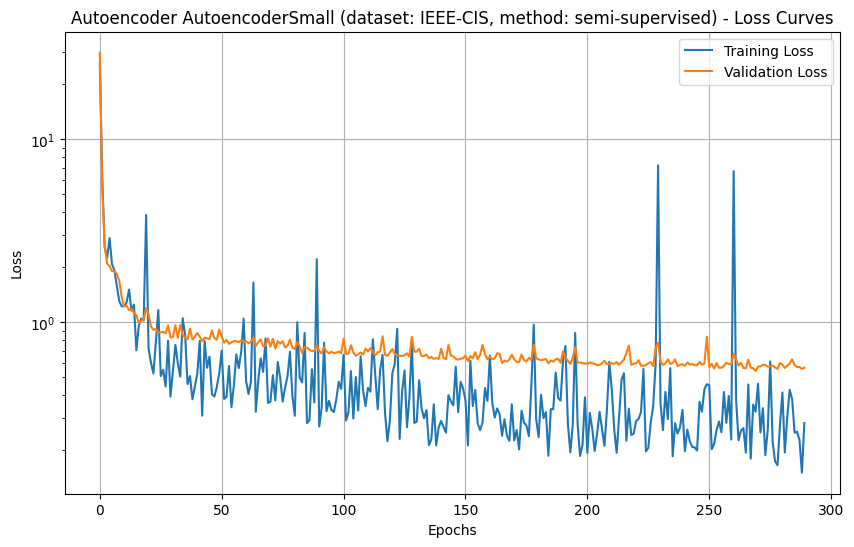

Evaluating Autoencoder AutoencoderSmall on test set...
Autoencoder AutoencoderSmall test loss computed.
test_loss mean: 415.8507
test_loss max: 146698.3438
test_loss min: 0.0341
test_loss std: 5830.3975
Autoencoder AutoencoderSmall (semi-supervised) (IEEE-CIS)
AUPRC: 0.0905
ROC AUC: 0.7287
Best F1 Threshold: 0.6522
At best F1 threshold - Precision: 0.1284, Recall: 0.3541, F1: 0.1885
Best Cost Threshold: 0.0419
At best cost threshold - Precision: 0.0345, Recall: 1.0000, F1: 0.0667


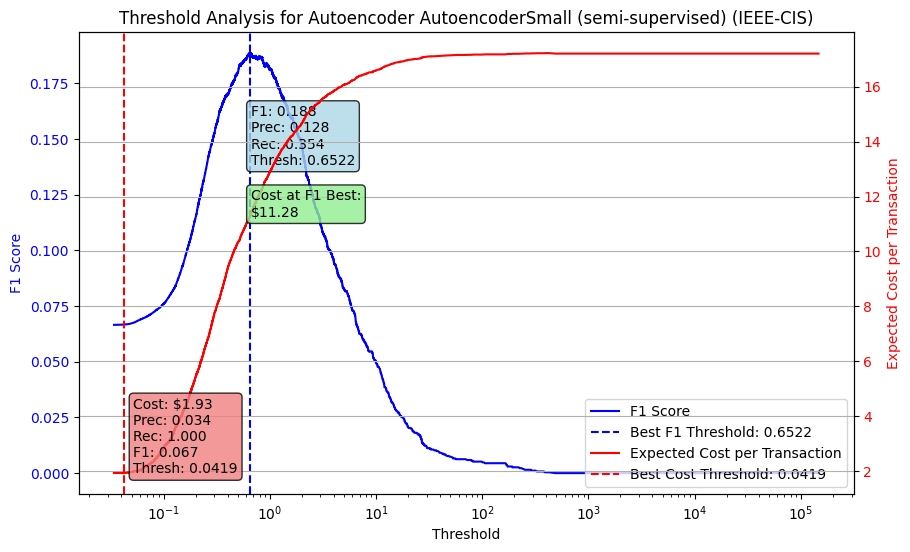

Starting Autoencoder training for AutoencoderLarge (dataset: IEEE-CIS, method: semi-supervised)...
Epoch [1/500], Loss: 24.5285
Epoch [2/500], Loss: 5.0311
Epoch [3/500], Loss: 4.8303
Epoch [4/500], Loss: 2.4958
Epoch [5/500], Loss: 2.1172
Epoch [6/500], Loss: 2.0597
Epoch [7/500], Loss: 1.5065
Epoch [8/500], Loss: 1.2182
Epoch [9/500], Loss: 1.0833
Epoch [10/500], Loss: 0.8317
Epoch [11/500], Loss: 1.2834
No improvement in loss. Stop counter: 1/20
Epoch [12/500], Loss: 0.5923
No improvement in loss. Stop counter: 2/20
Epoch [13/500], Loss: 1.0699
Epoch [14/500], Loss: 1.3694
Epoch [15/500], Loss: 0.7059
No improvement in loss. Stop counter: 1/20
Epoch [16/500], Loss: 0.6073
Epoch [17/500], Loss: 0.8391
No improvement in loss. Stop counter: 1/20
Epoch [18/500], Loss: 0.7193
No improvement in loss. Stop counter: 2/20
Epoch [19/500], Loss: 0.6578
Epoch [20/500], Loss: 0.7378
Epoch [21/500], Loss: 1.3905
Epoch [22/500], Loss: 0.6204
No improvement in loss. Stop counter: 1/20
Epoch [23/500

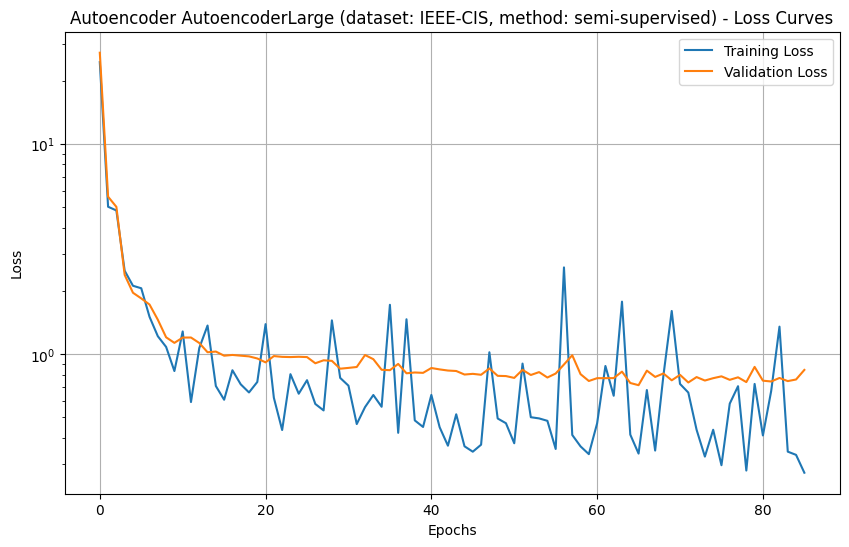

Evaluating Autoencoder AutoencoderLarge on test set...
Autoencoder AutoencoderLarge test loss computed.
test_loss mean: 544.7509
test_loss max: 206006.5625
test_loss min: 0.0622
test_loss std: 7976.3008
Autoencoder AutoencoderLarge (semi-supervised) (IEEE-CIS)
AUPRC: 0.0860
ROC AUC: 0.7084
Best F1 Threshold: 0.9986
At best F1 threshold - Precision: 0.1274, Recall: 0.3314, F1: 0.1841
Best Cost Threshold: 0.0732
At best cost threshold - Precision: 0.0344, Recall: 1.0000, F1: 0.0666


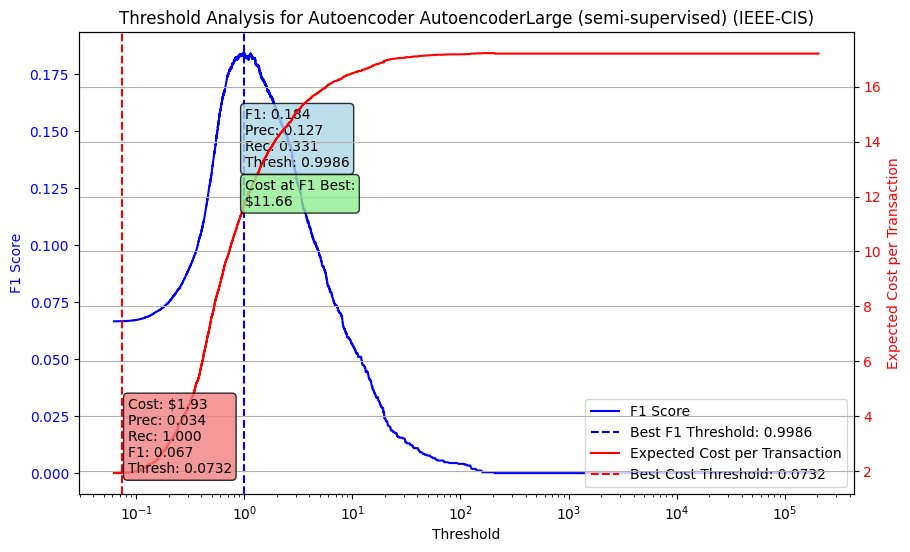

Training Autoencoders with supervised method (all data with class labels)...
Starting Autoencoder training for AutoencoderSmall (dataset: IEEE-CIS, method: supervised)...
Epoch [1/500], Loss: 29.9385
Epoch [2/500], Loss: 6.6110
Epoch [3/500], Loss: 6.5601
Epoch [4/500], Loss: 2.2306
Epoch [5/500], Loss: 2.7372
Epoch [6/500], Loss: 1.3104
Epoch [7/500], Loss: 1.3294
No improvement in loss. Stop counter: 1/20
Epoch [8/500], Loss: 1.3736
Epoch [9/500], Loss: 1.2198
Epoch [10/500], Loss: 2.8326
Epoch [11/500], Loss: 0.8148
Epoch [12/500], Loss: 1.0540
Epoch [13/500], Loss: 1.0164
Epoch [14/500], Loss: 0.9196
Epoch [15/500], Loss: 0.5925
No improvement in loss. Stop counter: 1/20
Epoch [16/500], Loss: 0.7255
Epoch [17/500], Loss: 2.2127
No improvement in loss. Stop counter: 1/20
Epoch [18/500], Loss: 1.0863
No improvement in loss. Stop counter: 2/20
Epoch [19/500], Loss: 0.4234
No improvement in loss. Stop counter: 3/20
Epoch [20/500], Loss: 0.7278
No improvement in loss. Stop counter: 4/20

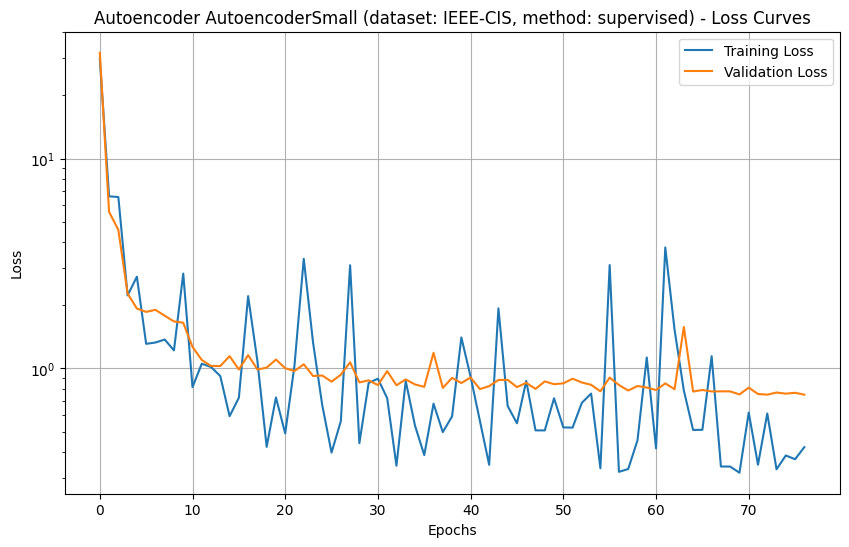

Evaluating Autoencoder AutoencoderSmall on test set...
Autoencoder AutoencoderSmall test loss computed.
test_loss mean: 551.1548
test_loss max: 197749.7188
test_loss min: 0.0666
test_loss std: 7802.7583
Autoencoder AutoencoderSmall (supervised) (IEEE-CIS)
AUPRC: 0.0844
ROC AUC: 0.7180
Best F1 Threshold: 0.8889
At best F1 threshold - Precision: 0.1207, Recall: 0.3462, F1: 0.1790
Best Cost Threshold: 0.0728
At best cost threshold - Precision: 0.0344, Recall: 1.0000, F1: 0.0665


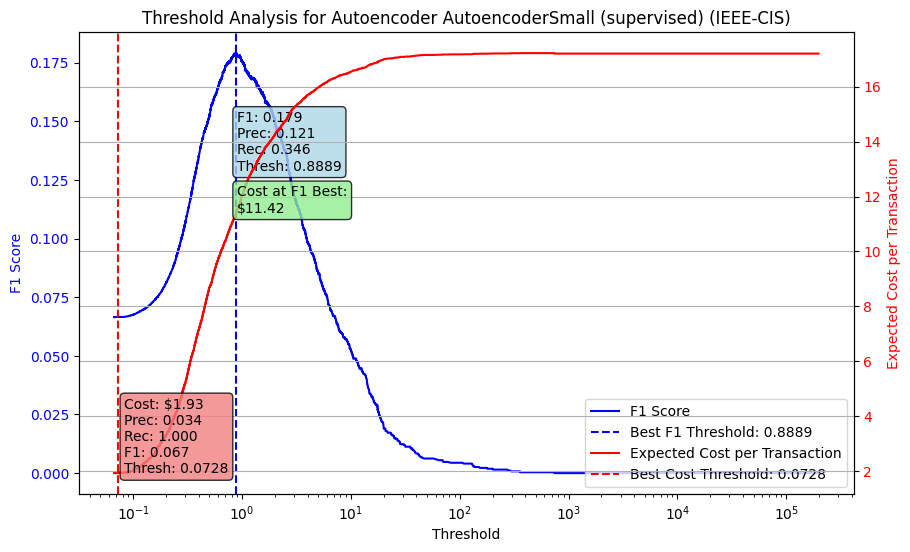

Starting Autoencoder training for AutoencoderLarge (dataset: IEEE-CIS, method: supervised)...
Epoch [1/500], Loss: 32.2357
Epoch [2/500], Loss: 4.8430
Epoch [3/500], Loss: 5.2171
No improvement in loss. Stop counter: 1/20
Epoch [4/500], Loss: 3.8022
Epoch [5/500], Loss: 1.4051
Epoch [6/500], Loss: 1.4118
Epoch [7/500], Loss: 1.4172
No improvement in loss. Stop counter: 1/20
Epoch [8/500], Loss: 1.4296
Epoch [9/500], Loss: 1.9136
Epoch [10/500], Loss: 0.8747
Epoch [11/500], Loss: 0.7736
No improvement in loss. Stop counter: 1/20
Epoch [12/500], Loss: 0.7851
No improvement in loss. Stop counter: 2/20
Epoch [13/500], Loss: 5.2700
No improvement in loss. Stop counter: 3/20
Epoch [14/500], Loss: 0.7700
Epoch [15/500], Loss: 0.5852
No improvement in loss. Stop counter: 1/20
Epoch [16/500], Loss: 0.6753
Epoch [17/500], Loss: 0.5383
Epoch [18/500], Loss: 0.6874
No improvement in loss. Stop counter: 1/20
Epoch [19/500], Loss: 0.7342
No improvement in loss. Stop counter: 2/20
Epoch [20/500], Los

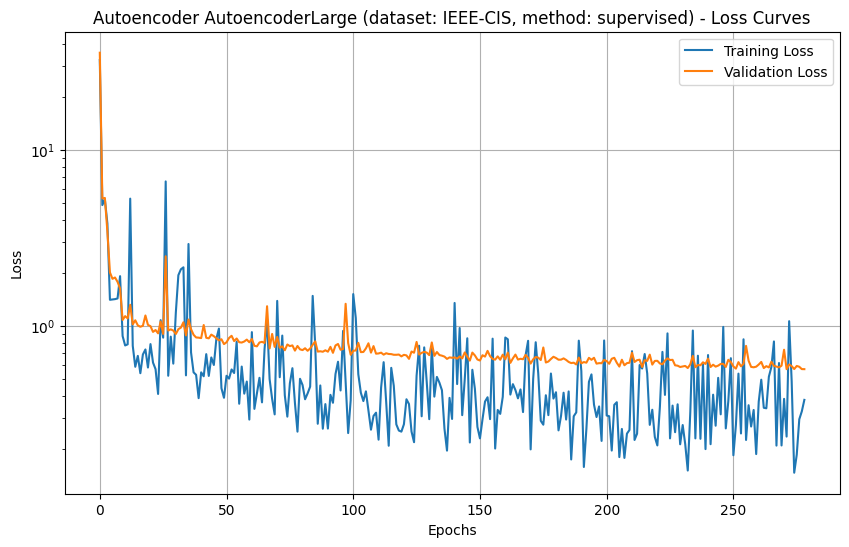

Evaluating Autoencoder AutoencoderLarge on test set...
Autoencoder AutoencoderLarge test loss computed.
test_loss mean: 386.1316
test_loss max: 139840.0469
test_loss min: 0.0294
test_loss std: 5487.3794
Autoencoder AutoencoderLarge (supervised) (IEEE-CIS)
AUPRC: 0.0856
ROC AUC: 0.7250
Best F1 Threshold: 0.6758
At best F1 threshold - Precision: 0.1225, Recall: 0.3484, F1: 0.1813
Best Cost Threshold: 0.0363
At best cost threshold - Precision: 0.0345, Recall: 1.0000, F1: 0.0666


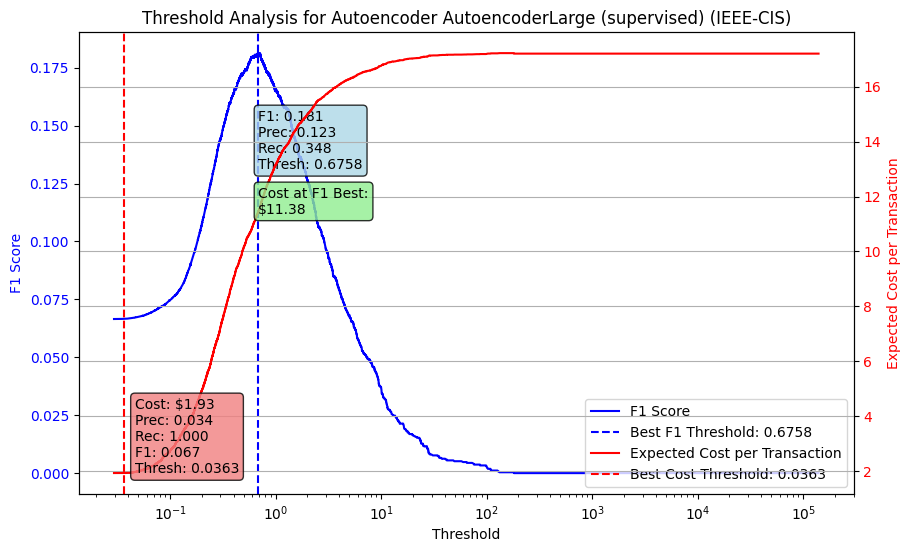

Training and evaluating Autoencoders on Credit Card Fraud dataset...
Autoencoder architecture defined.
Preparing data for Autoencoder...
Training Autoencoders with semi-supervised method (normal data only)...
Starting Autoencoder training for AutoencoderSmall (dataset: Credit Card Fraud, method: semi-supervised)...
Epoch [1/500], Loss: 0.5089
Epoch [2/500], Loss: 0.3062
Epoch [3/500], Loss: 0.3756
Epoch [4/500], Loss: 0.1599
Epoch [5/500], Loss: 0.1188
Epoch [6/500], Loss: 0.1615
Epoch [7/500], Loss: 0.1492
Epoch [8/500], Loss: 0.1069
Epoch [9/500], Loss: 0.0677
No improvement in loss. Stop counter: 1/20
Epoch [10/500], Loss: 0.0612
Epoch [11/500], Loss: 0.1064
Epoch [12/500], Loss: 0.0501
Epoch [13/500], Loss: 0.2579
No improvement in loss. Stop counter: 1/20
Epoch [14/500], Loss: 0.0418
Epoch [15/500], Loss: 0.0384
No improvement in loss. Stop counter: 1/20
Epoch [16/500], Loss: 0.0357
Epoch [17/500], Loss: 0.0281
No improvement in loss. Stop counter: 1/20
Epoch [18/500], Loss: 0.058

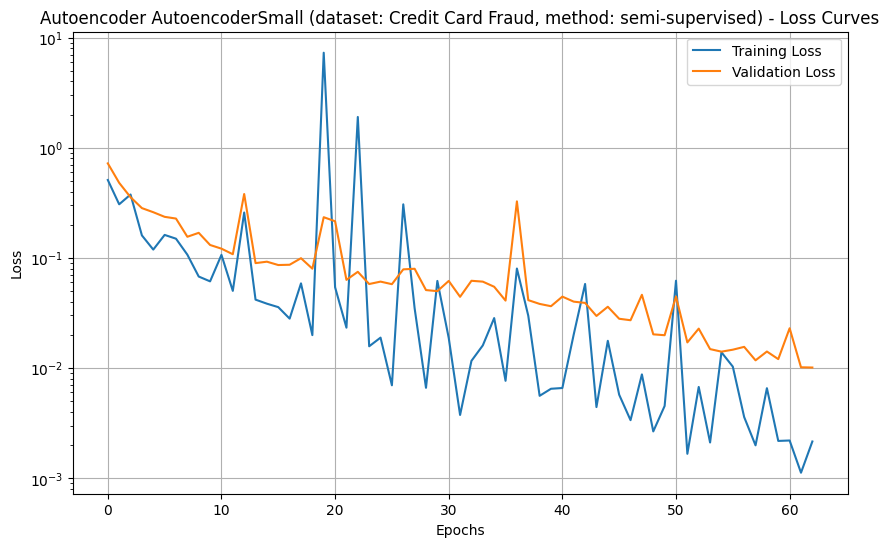

Evaluating Autoencoder AutoencoderSmall on test set...
Autoencoder AutoencoderSmall test loss computed.
test_loss mean: 0.0101
test_loss max: 13.9966
test_loss min: 0.0000
test_loss std: 0.1568
Autoencoder AutoencoderSmall (semi-supervised) (Credit Card Fraud)
AUPRC: 0.4082
ROC AUC: 0.9359
Best F1 Threshold: 0.4198
At best F1 threshold - Precision: 0.3986, Recall: 0.6627, F1: 0.4977
Best Cost Threshold: 0.0372
At best cost threshold - Precision: 0.0680, Recall: 0.8072, F1: 0.1254


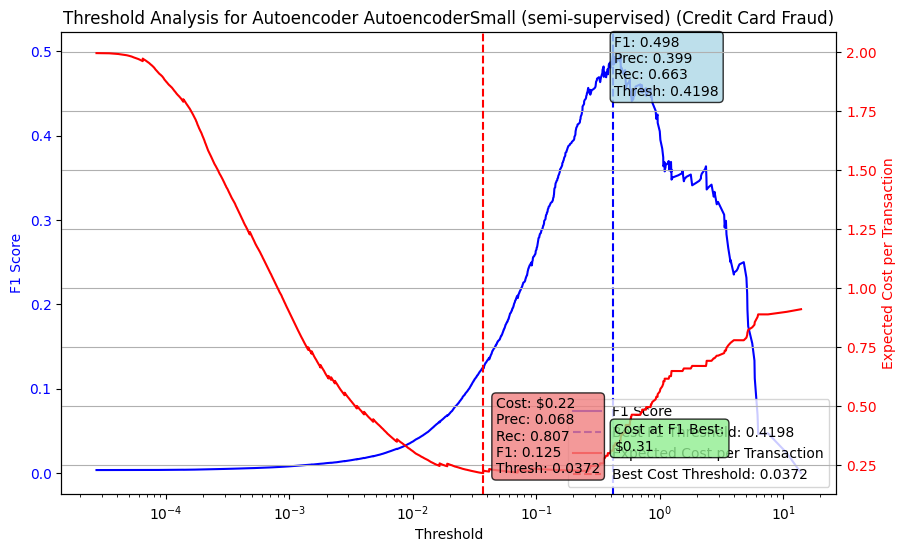

Starting Autoencoder training for AutoencoderLarge (dataset: Credit Card Fraud, method: semi-supervised)...
Epoch [1/500], Loss: 0.4404
Epoch [2/500], Loss: 2.2859
Epoch [3/500], Loss: 0.5561
No improvement in loss. Stop counter: 1/20
Epoch [4/500], Loss: 0.2221
Epoch [5/500], Loss: 0.1836
Epoch [6/500], Loss: 0.1495
Epoch [7/500], Loss: 0.0918
Epoch [8/500], Loss: 0.1447
Epoch [9/500], Loss: 0.2069
Epoch [10/500], Loss: 0.0378
Epoch [11/500], Loss: 0.0332
Epoch [12/500], Loss: 0.0757
No improvement in loss. Stop counter: 1/20
Epoch [13/500], Loss: 0.8026
No improvement in loss. Stop counter: 2/20
Epoch [14/500], Loss: 0.0457
Epoch [15/500], Loss: 0.5654
No improvement in loss. Stop counter: 1/20
Epoch [16/500], Loss: 0.0867
No improvement in loss. Stop counter: 2/20
Epoch [17/500], Loss: 0.0452
No improvement in loss. Stop counter: 3/20
Epoch [18/500], Loss: 0.0216
Epoch [19/500], Loss: 0.0334
No improvement in loss. Stop counter: 1/20
Epoch [20/500], Loss: 0.0119
Epoch [21/500], Loss

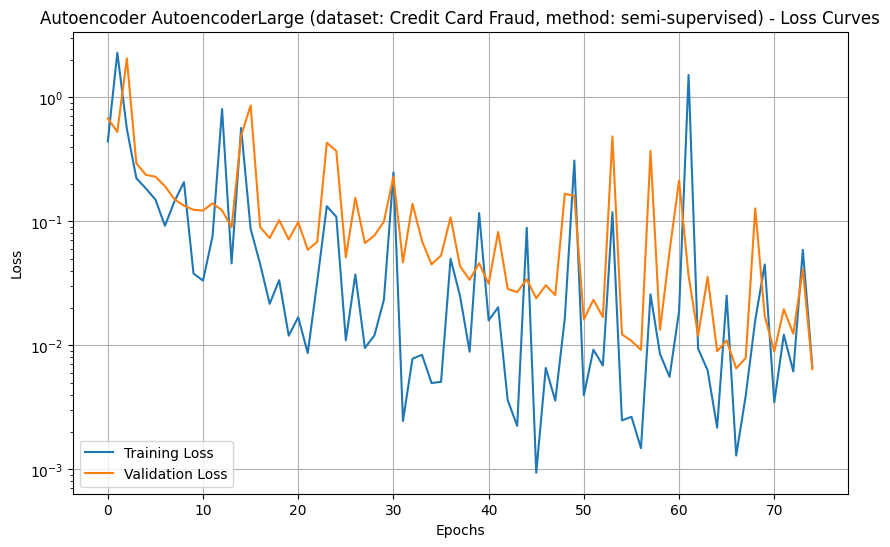

Evaluating Autoencoder AutoencoderLarge on test set...
Autoencoder AutoencoderLarge test loss computed.
test_loss mean: 0.0064
test_loss max: 19.4292
test_loss min: 0.0000
test_loss std: 0.1565
Autoencoder AutoencoderLarge (semi-supervised) (Credit Card Fraud)
AUPRC: 0.4682
ROC AUC: 0.9403
Best F1 Threshold: 0.2323
At best F1 threshold - Precision: 0.4715, Recall: 0.6988, F1: 0.5631
Best Cost Threshold: 0.0582
At best cost threshold - Precision: 0.1679, Recall: 0.7952, F1: 0.2773


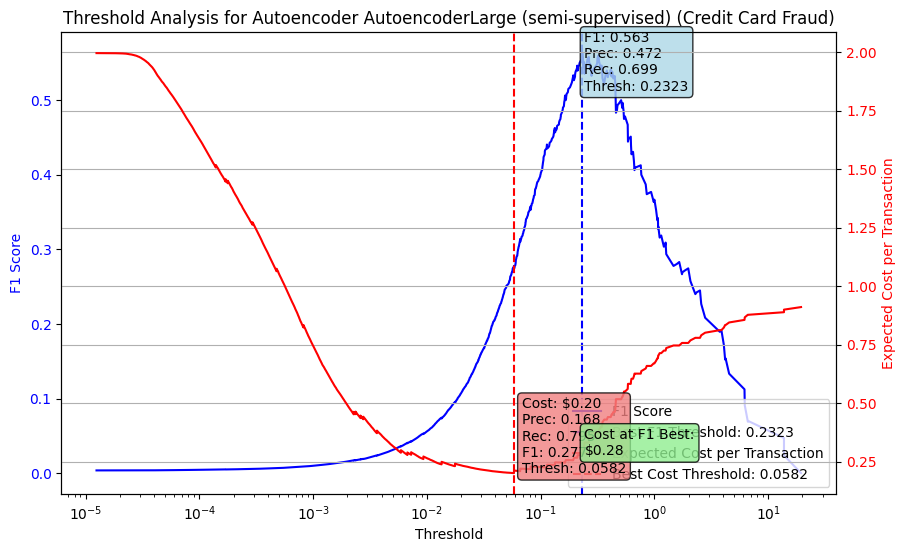

Training Autoencoders with supervised method (all data with class labels)...
Starting Autoencoder training for AutoencoderSmall (dataset: Credit Card Fraud, method: supervised)...
Epoch [1/500], Loss: 0.4733
Epoch [2/500], Loss: 0.3892
Epoch [3/500], Loss: 0.5083
Epoch [4/500], Loss: 0.4102
Epoch [5/500], Loss: 0.2487
Epoch [6/500], Loss: 0.1155
Epoch [7/500], Loss: 0.2252
No improvement in loss. Stop counter: 1/20
Epoch [8/500], Loss: 0.1261
Epoch [9/500], Loss: 0.2833
Epoch [10/500], Loss: 0.0872
Epoch [11/500], Loss: 0.0709
No improvement in loss. Stop counter: 1/20
Epoch [12/500], Loss: 0.0513
Epoch [13/500], Loss: 0.0469
Epoch [14/500], Loss: 0.0219
Epoch [15/500], Loss: 0.0274
Epoch [16/500], Loss: 0.0275
No improvement in loss. Stop counter: 1/20
Epoch [17/500], Loss: 0.0272
No improvement in loss. Stop counter: 2/20
Epoch [18/500], Loss: 0.0164
Epoch [19/500], Loss: 0.0110
No improvement in loss. Stop counter: 1/20
Epoch [20/500], Loss: 0.0083
Epoch [21/500], Loss: 0.0091
No im

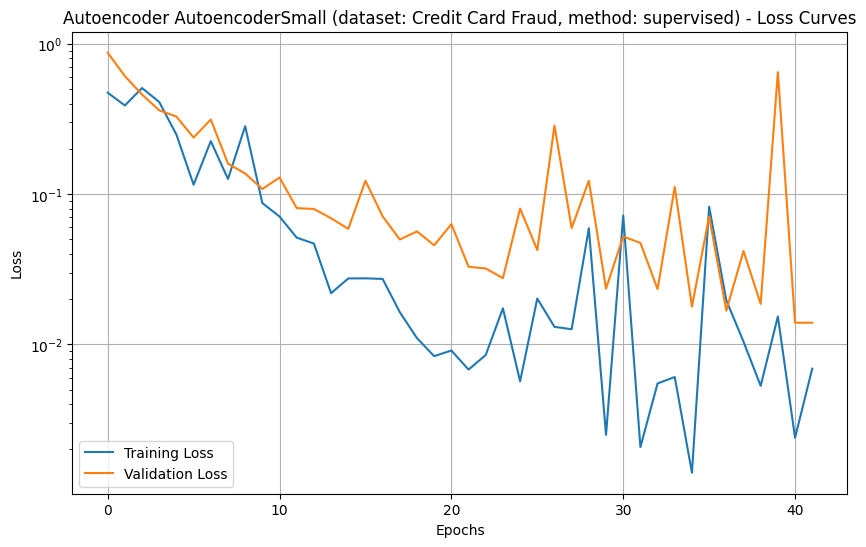

Evaluating Autoencoder AutoencoderSmall on test set...
Autoencoder AutoencoderSmall test loss computed.
test_loss mean: 0.0139
test_loss max: 17.9920
test_loss min: 0.0001
test_loss std: 0.1771
Autoencoder AutoencoderSmall (supervised) (Credit Card Fraud)
AUPRC: 0.0633
ROC AUC: 0.9269
Best F1 Threshold: 0.1909
At best F1 threshold - Precision: 0.0921, Recall: 0.4096, F1: 0.1504
Best Cost Threshold: 0.0324
At best cost threshold - Precision: 0.0303, Recall: 0.8313, F1: 0.0585


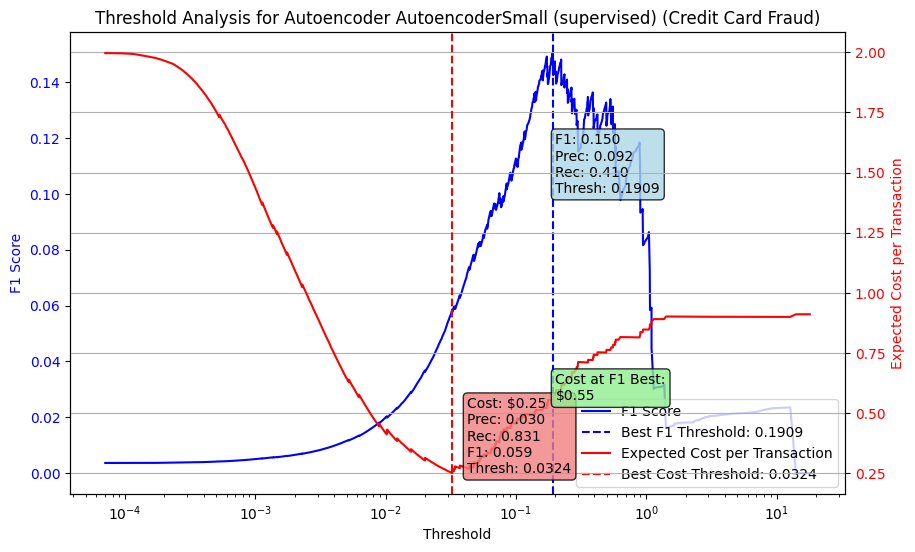

Starting Autoencoder training for AutoencoderLarge (dataset: Credit Card Fraud, method: supervised)...
Epoch [1/500], Loss: 0.8153
Epoch [2/500], Loss: 0.4400
Epoch [3/500], Loss: 0.2814
Epoch [4/500], Loss: 0.3606
Epoch [5/500], Loss: 0.1062
No improvement in loss. Stop counter: 1/20
Epoch [6/500], Loss: 0.1818
Epoch [7/500], Loss: 0.1054
Epoch [8/500], Loss: 0.1495
Epoch [9/500], Loss: 0.0760
No improvement in loss. Stop counter: 1/20
Epoch [10/500], Loss: 0.0682
Epoch [11/500], Loss: 0.0775
No improvement in loss. Stop counter: 1/20
Epoch [12/500], Loss: 0.0454
Epoch [13/500], Loss: 0.0498
No improvement in loss. Stop counter: 1/20
Epoch [14/500], Loss: 0.0861
No improvement in loss. Stop counter: 2/20
Epoch [15/500], Loss: 0.0167
Epoch [16/500], Loss: 0.3274
Epoch [17/500], Loss: 0.0171
Epoch [18/500], Loss: 0.0190
No improvement in loss. Stop counter: 1/20
Epoch [19/500], Loss: 0.0247
No improvement in loss. Stop counter: 2/20
Epoch [20/500], Loss: 0.0092
No improvement in loss. S

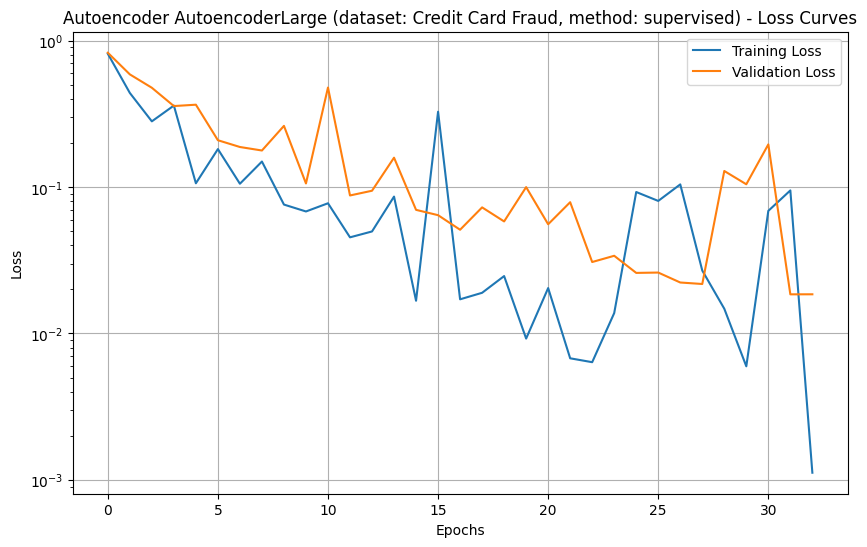

Evaluating Autoencoder AutoencoderLarge on test set...
Autoencoder AutoencoderLarge test loss computed.
test_loss mean: 0.0185
test_loss max: 30.3232
test_loss min: 0.0002
test_loss std: 0.2173
Autoencoder AutoencoderLarge (supervised) (Credit Card Fraud)
AUPRC: 0.0241
ROC AUC: 0.9024
Best F1 Threshold: 0.1755
At best F1 threshold - Precision: 0.0416, Recall: 0.2530, F1: 0.0714
Best Cost Threshold: 0.0262
At best cost threshold - Precision: 0.0162, Recall: 0.7831, F1: 0.0317


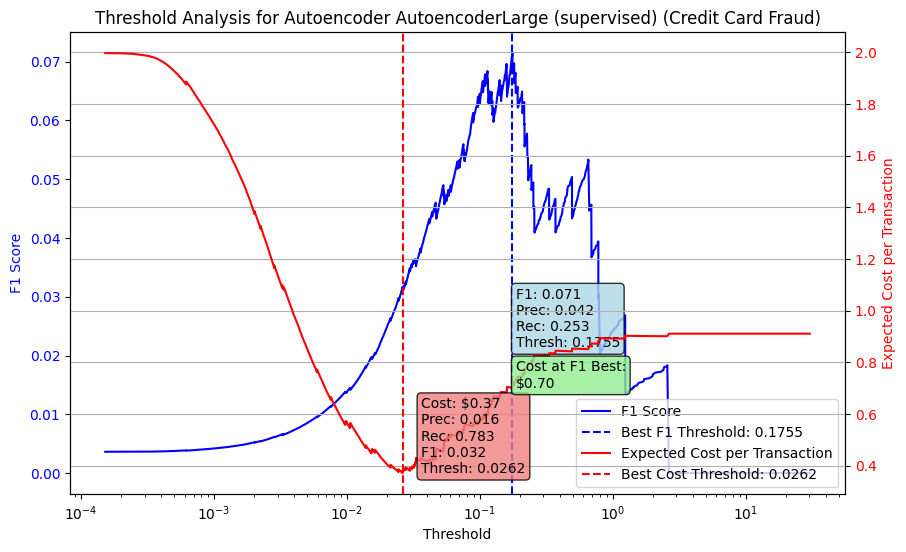

In [44]:
# Train and evaluate autoencoders for anomaly detection, while tracking the best model state for potential ensemble use later. Also plot loss curves to visualize training progress and potential overfitting.

# IEEE CIS dataset
# print("Training and evaluating Autoencoders on IEEE CIS dataset...")
autoencoder_best_state_list = train_and_evaluate_autoencoders(X_train_dnn, y_train_dnn, X_val_dnn, X_val, y_val, dataset_name="IEEE-CIS")  

# Credit card fraud dataset
print("Training and evaluating Autoencoders on Credit Card Fraud dataset...")
autoencoder_best_state_list_ccf = train_and_evaluate_autoencoders(X_train_dnn_ccf, y_train_dnn_ccf, X_val_dnn_ccf, X_val_dnn_ccf, y_val_dnn_ccf, dataset_name="Credit Card Fraud") 

DNN - Supervised Learning

Training and evaluating DNN supervised classifiers...
Training and evaluating DNN supervised classifiers on IEEE CIS dataset...
Starting DNN training for DNNClassifierMLP (dataset: IEEE-CIS)...
Epoch [1/500], Validation Loss: 0.5315
Epoch [2/500], Validation Loss: 0.4904
Epoch [3/500], Validation Loss: 0.7527
No improvement in validation loss. Stop counter: 1/20
Epoch [4/500], Validation Loss: 0.4794
Epoch [5/500], Validation Loss: 0.5207
No improvement in validation loss. Stop counter: 1/20
Epoch [6/500], Validation Loss: 0.7086
No improvement in validation loss. Stop counter: 2/20
Epoch [7/500], Validation Loss: 0.4944
No improvement in validation loss. Stop counter: 3/20
Epoch [8/500], Validation Loss: 0.5257
No improvement in validation loss. Stop counter: 4/20
Epoch [9/500], Validation Loss: 0.4774
Epoch [10/500], Validation Loss: 0.4875
No improvement in validation loss. Stop counter: 1/20
Epoch [11/500], Validation Loss: 0.5220
No improvement in validation loss. Stop counter: 2/

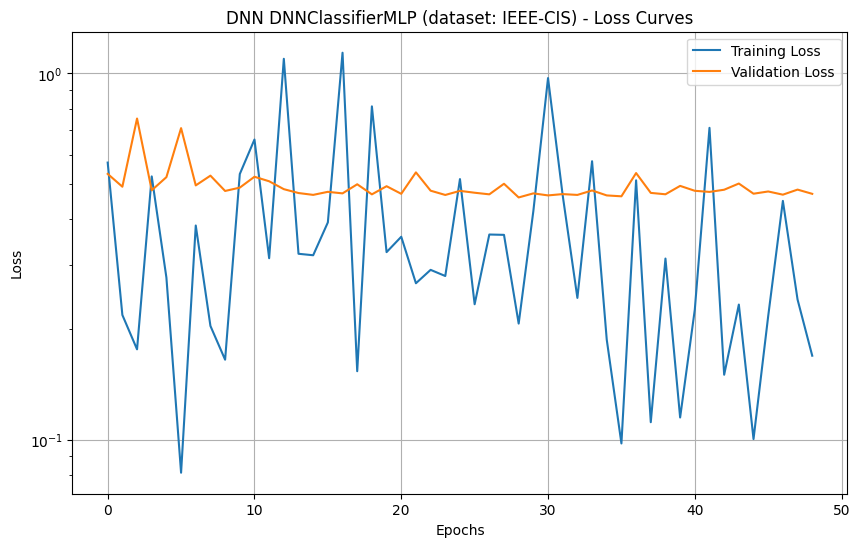

Evaluating DNN DNNClassifierMLP on validation set...
DNN DNNClassifierMLP validation loss: 0.5807
DNN DNNClassifierMLP (IEEE-CIS)
AUPRC: 0.3479
ROC AUC: 0.8285
Best F1 Threshold: 0.9610
At best F1 threshold - Precision: 0.4111, Recall: 0.3467, F1: 0.3762
Best Cost Threshold: 0.0000
At best cost threshold - Precision: 0.0348, Recall: 1.0000, F1: 0.0673


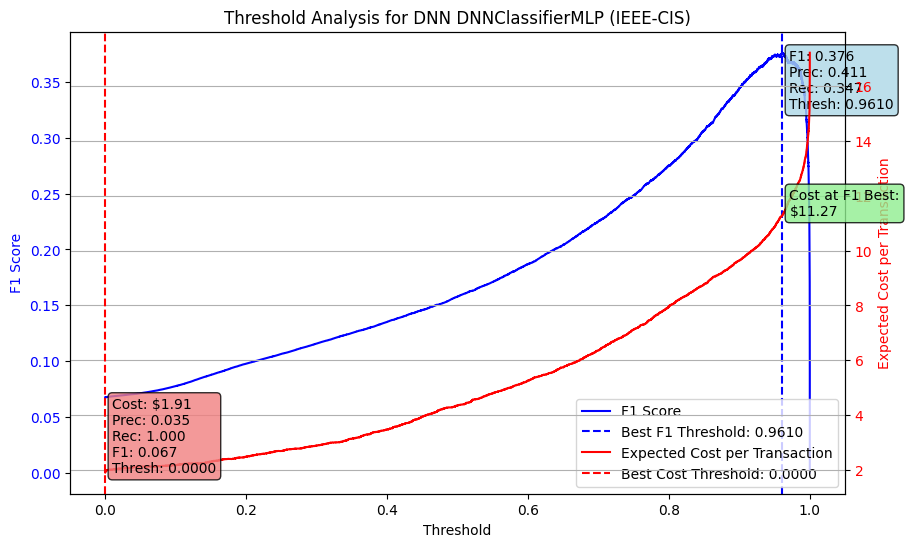

Starting DNN training for DNNClassifierResNet (dataset: IEEE-CIS)...
Epoch [1/500], Validation Loss: 0.6132
Epoch [2/500], Validation Loss: 1.4498
No improvement in validation loss. Stop counter: 1/20
Epoch [3/500], Validation Loss: 1.1711
No improvement in validation loss. Stop counter: 2/20
Epoch [4/500], Validation Loss: 1.1038
No improvement in validation loss. Stop counter: 3/20
Epoch [5/500], Validation Loss: 0.8640
No improvement in validation loss. Stop counter: 4/20
Epoch [6/500], Validation Loss: 0.5921
Epoch [7/500], Validation Loss: 0.5353
Epoch [8/500], Validation Loss: 0.5027
Epoch [9/500], Validation Loss: 0.5019
Epoch [10/500], Validation Loss: 0.5807
No improvement in validation loss. Stop counter: 1/20
Epoch [11/500], Validation Loss: 0.5427
No improvement in validation loss. Stop counter: 2/20
Epoch [12/500], Validation Loss: 0.7536
No improvement in validation loss. Stop counter: 3/20
Epoch [13/500], Validation Loss: 0.7558
No improvement in validation loss. Stop co

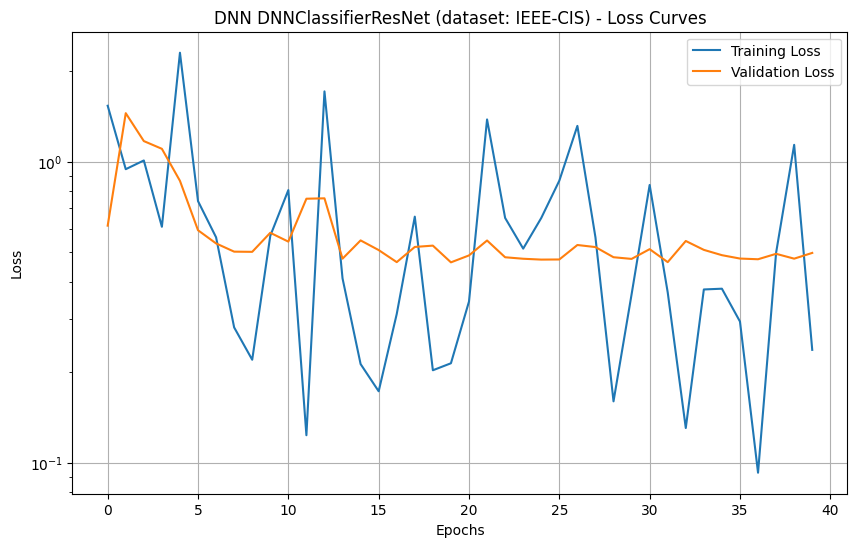

Evaluating DNN DNNClassifierResNet on validation set...
DNN DNNClassifierResNet validation loss: 0.5319
DNN DNNClassifierResNet (IEEE-CIS)
AUPRC: 0.3156
ROC AUC: 0.8243
Best F1 Threshold: 0.8570
At best F1 threshold - Precision: 0.3998, Recall: 0.3236, F1: 0.3577
Best Cost Threshold: 0.0000
At best cost threshold - Precision: 0.0348, Recall: 1.0000, F1: 0.0673


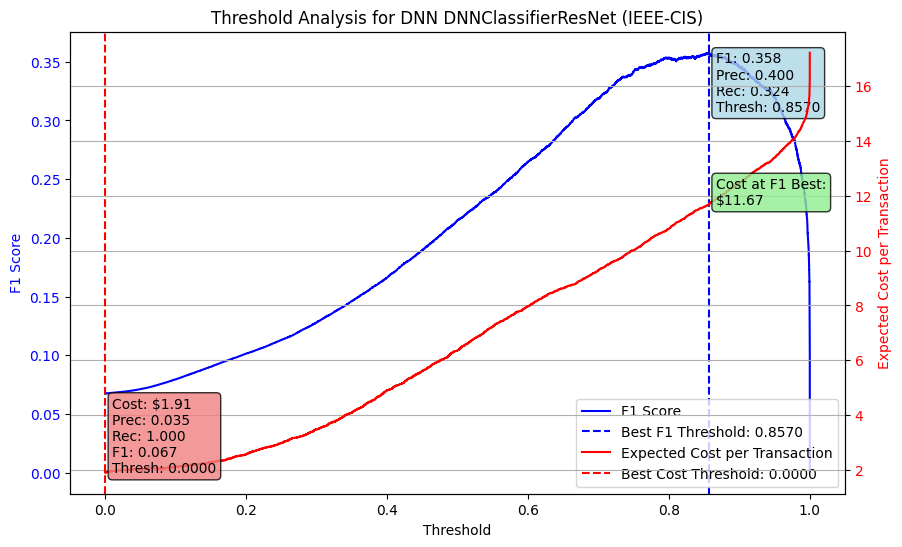

Training and evaluating DNN supervised classifiers on Credit Card Fraud dataset...
Starting DNN training for DNNClassifierMLP (dataset: Credit-Card-Fraud)...
Epoch [1/500], Validation Loss: 0.0954
Epoch [2/500], Validation Loss: 0.0516
Epoch [3/500], Validation Loss: 0.0600
No improvement in validation loss. Stop counter: 1/20
Epoch [4/500], Validation Loss: 0.0485
Epoch [5/500], Validation Loss: 0.0428
Epoch [6/500], Validation Loss: 0.0433
No improvement in validation loss. Stop counter: 1/20
Epoch [7/500], Validation Loss: 0.0651
No improvement in validation loss. Stop counter: 2/20
Epoch [8/500], Validation Loss: 0.0746
No improvement in validation loss. Stop counter: 3/20
Epoch [9/500], Validation Loss: 0.0530
No improvement in validation loss. Stop counter: 4/20
Epoch [10/500], Validation Loss: 0.0415
Epoch [11/500], Validation Loss: 0.0395
Epoch [12/500], Validation Loss: 0.0342
Epoch [13/500], Validation Loss: 0.0572
No improvement in validation loss. Stop counter: 1/20
Epoch [

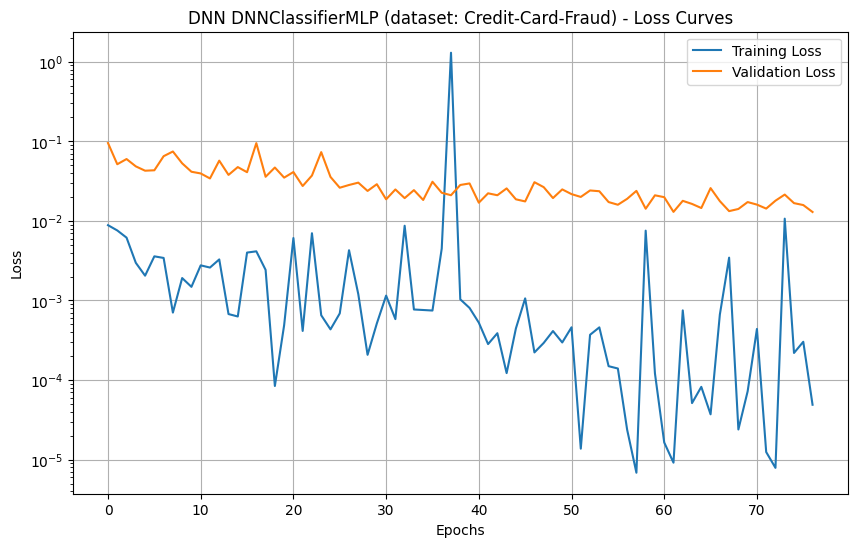

Evaluating DNN DNNClassifierMLP on validation set...
DNN DNNClassifierMLP validation loss: 0.0441
DNN DNNClassifierMLP (Credit-Card-Fraud)
AUPRC: 0.8830
ROC AUC: 0.9740
Best F1 Threshold: 0.9766
At best F1 threshold - Precision: 0.9082, Recall: 0.8476, F1: 0.8768
Best Cost Threshold: 0.0638
At best cost threshold - Precision: 0.1854, Recall: 0.9429, F1: 0.3099


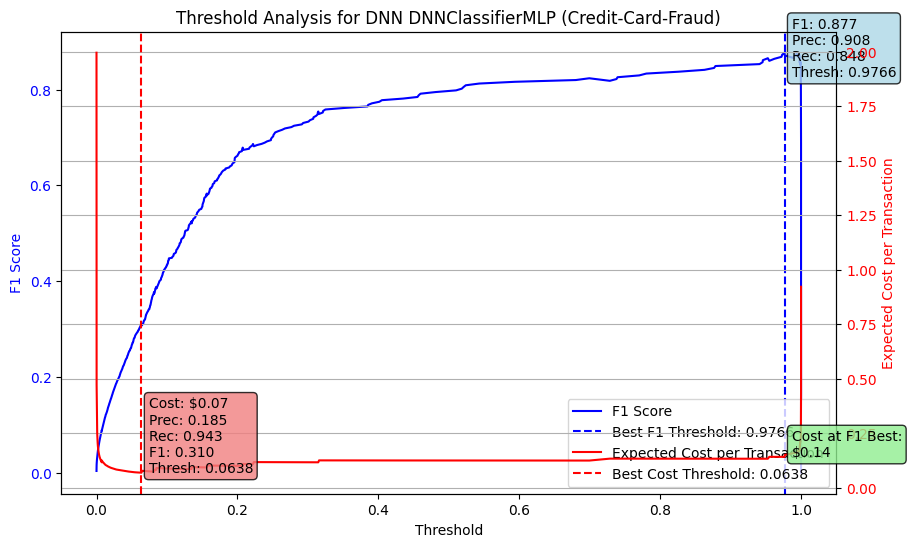

Starting DNN training for DNNClassifierResNet (dataset: Credit-Card-Fraud)...
Epoch [1/500], Validation Loss: 0.0900
Epoch [2/500], Validation Loss: 0.0414
Epoch [3/500], Validation Loss: 0.0631
No improvement in validation loss. Stop counter: 1/20
Epoch [4/500], Validation Loss: 0.0436
No improvement in validation loss. Stop counter: 2/20
Epoch [5/500], Validation Loss: 0.0455
No improvement in validation loss. Stop counter: 3/20
Epoch [6/500], Validation Loss: 0.0391
Epoch [7/500], Validation Loss: 0.0752
No improvement in validation loss. Stop counter: 1/20
Epoch [8/500], Validation Loss: 0.0720
No improvement in validation loss. Stop counter: 2/20
Epoch [9/500], Validation Loss: 0.0676
No improvement in validation loss. Stop counter: 3/20
Epoch [10/500], Validation Loss: 0.0296
Epoch [11/500], Validation Loss: 0.0759
No improvement in validation loss. Stop counter: 1/20
Epoch [12/500], Validation Loss: 0.0396
No improvement in validation loss. Stop counter: 2/20
Epoch [13/500], Val

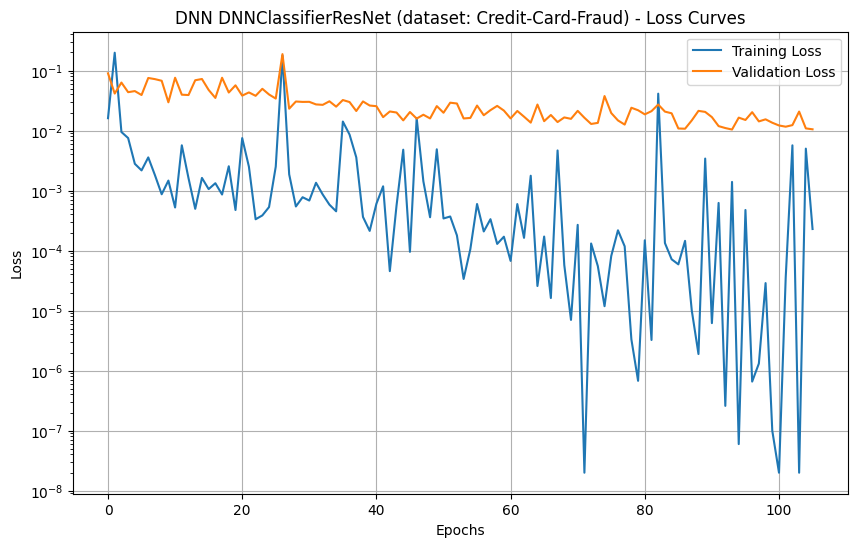

Evaluating DNN DNNClassifierResNet on validation set...
DNN DNNClassifierResNet validation loss: 0.0728
DNN DNNClassifierResNet (Credit-Card-Fraud)
AUPRC: 0.8824
ROC AUC: 0.9724
Best F1 Threshold: 0.8527
At best F1 threshold - Precision: 0.9020, Recall: 0.8762, F1: 0.8889
Best Cost Threshold: 0.1307
At best cost threshold - Precision: 0.3493, Recall: 0.9048, F1: 0.5040


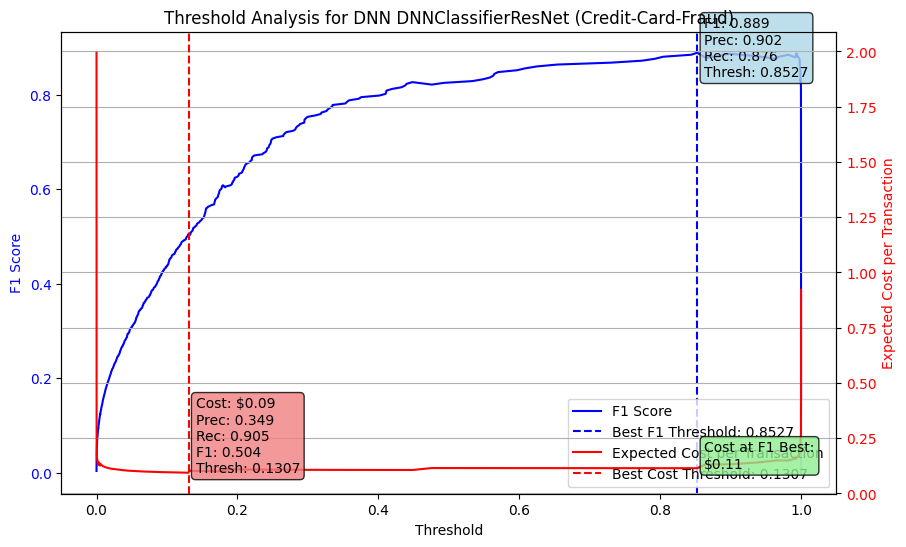

In [42]:
# Train and evaluate DNN supervised classifiers, while tracking the best model state for potential ensemble use later. Also plot loss curves to visualize training progress and potential overfitting.
print("Training and evaluating DNN supervised classifiers...")

# IEEE CIS dataset
print("Training and evaluating DNN supervised classifiers on IEEE CIS dataset...")
dnn_best_state_list = train_and_evaluate_dnn(input_dim, num_classes=2, X_train_dnn=X_train_dnn, y_train_dnn=y_train_dnn, X_val_dnn=X_val_dnn, y_val_dnn=y_val_dnn, X_test_dnn=X_val, y_test_dnn=y_val, scale_pos_weight=scale_pos_weight, dataset_name="IEEE-CIS")

# Credit card fraud dataset
print("Training and evaluating DNN supervised classifiers on Credit Card Fraud dataset...")
dnn_best_state_list = train_and_evaluate_dnn(input_dim_ccf, num_classes=2, X_train_dnn=X_train_ccf, y_train_dnn=y_train_ccf, X_val_dnn=X_val_dnn_ccf, y_val_dnn=y_val_dnn_ccf, X_test_dnn=X_test_ccf, y_test_dnn=y_test_ccf, scale_pos_weight=scale_pos_weight, dataset_name="Credit-Card-Fraud")

Error Analysis

Best model on IEEE-CIS dataset based on validation performance: XGBoost
Best model on IEEE-CIS dataset selected: XGBoost
Plotting false positive and false negative examples for the best model on IEEE-CIS dataset...
Number of false positive and false negative examples to plot: 20
Plotting false positive examples for XGBoost on IEEE-CIS...


C:\Users\Admin\AppData\Local\Temp\ipykernel_2916\1839931620.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(X_false_positives.values, labels=X_false_positives.columns)


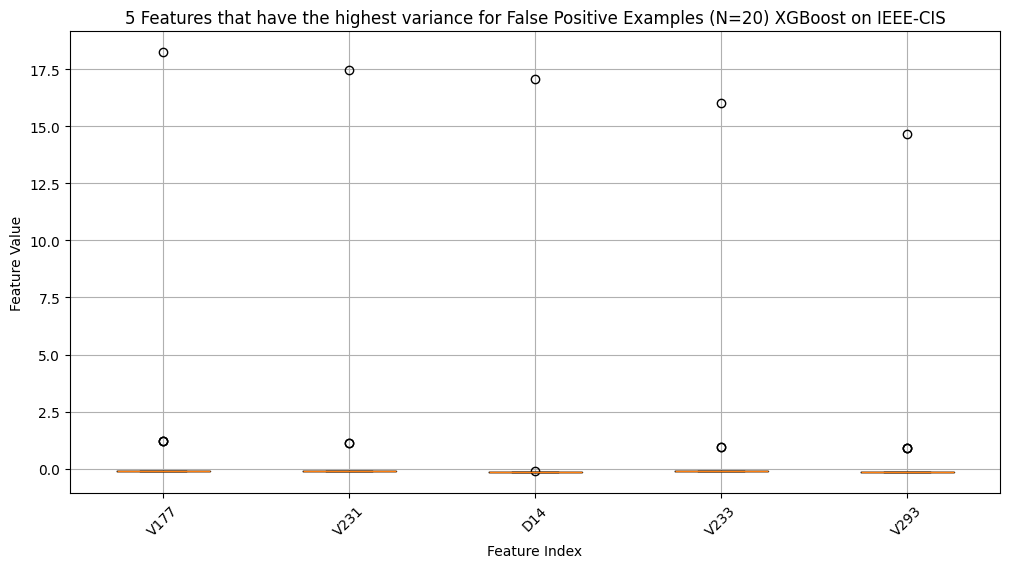

C:\Users\Admin\AppData\Local\Temp\ipykernel_2916\2533622591.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(X_false_negatives.values, labels=X_false_negatives.columns)


Plotting false negative examples for XGBoost on IEEE-CIS...


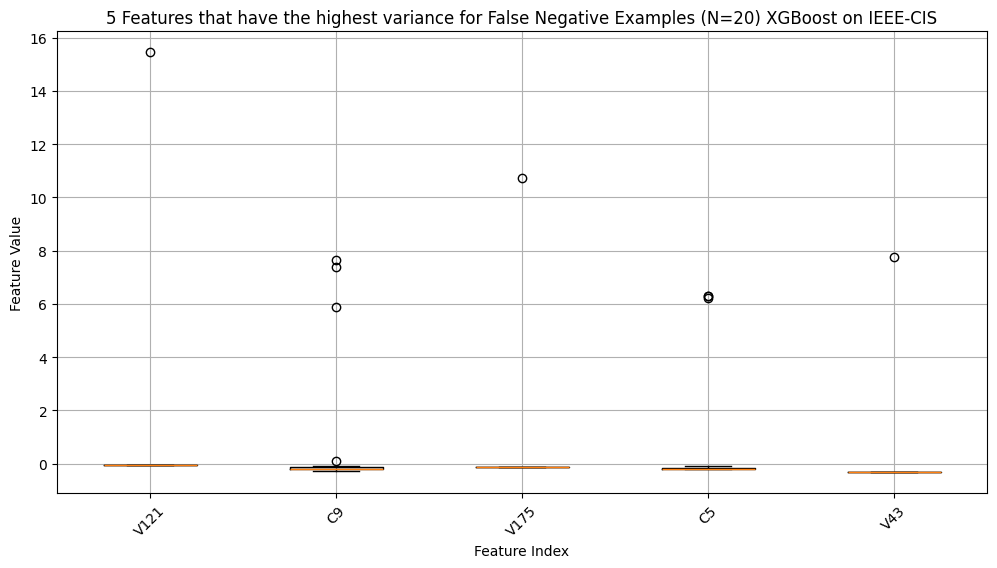

In [ ]:
# Choose the best model performing on the IEEE-CIS dataset based on validation performance
best_model_name = "XGBoost" 
print(f"Best model on IEEE-CIS dataset based on validation performance: {best_model_name}")

best_model_IEEE_CIS = None
if best_model_name == "Isolation Forest":
    best_model_IEEE_CIS = scores_iso_val
elif best_model_name == "Local Outlier Factor":
    best_model_IEEE_CIS = scores_lof_val
elif best_model_name == "XGBoost":
    best_model_IEEE_CIS = scores_xgb_val
elif best_model_name.startswith("Autoencoder"):
    best_model_IEEE_CIS = autoencoder_best_state_list[0]  # Assuming the first autoencoder is the best, adjust as needed
elif best_model_name.startswith("DNN"):
    best_model_IEEE_CIS = dnn_best_state_list[0]  # Assuming the first DNN is the best, adjust as needed
print(f"Best model on IEEE-CIS dataset selected: {best_model_name}")    

print("Plotting false positive and false negative examples for the best model on IEEE-CIS dataset...")

# Visualize False Positives and False Negatives for the best model on the IEEE-CIS dataset to gain insights into what kind of transactions are being misclassified, which can help identify potential areas for improvement in the model.
num_example_FP_FN = 20
print(f"Number of false positive and false negative examples to plot: {num_example_FP_FN}")

# Plot false positive examples from the best model on the IEEE-CIS dataset to visualize what kind of transactions are being misclassified as fraudulent, which can provide insights into potential areas for improvement in the model.
plot_false_positives(best_model_IEEE_CIS, X_val_numeric, y_val, best_model_name, dataset_name="IEEE-CIS", num_examples=num_example_FP_FN)


# Plot false negative examples from the best model on the IEEE-CIS dataset to visualize what kind of fraudulent transactions are being misclassified as non-fraudulent, which can provide insights into potential areas for improvement in the model.
plot_false_negatives(best_model_IEEE_CIS, X_val_numeric, y_val, best_model_name, dataset_name="IEEE-CIS", num_examples=num_example_FP_FN)

Precision-recall curve of the best model

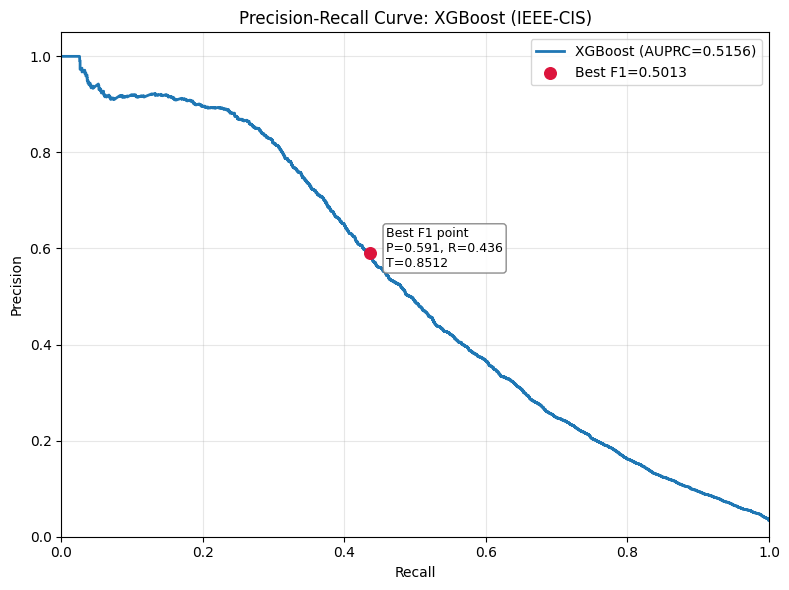

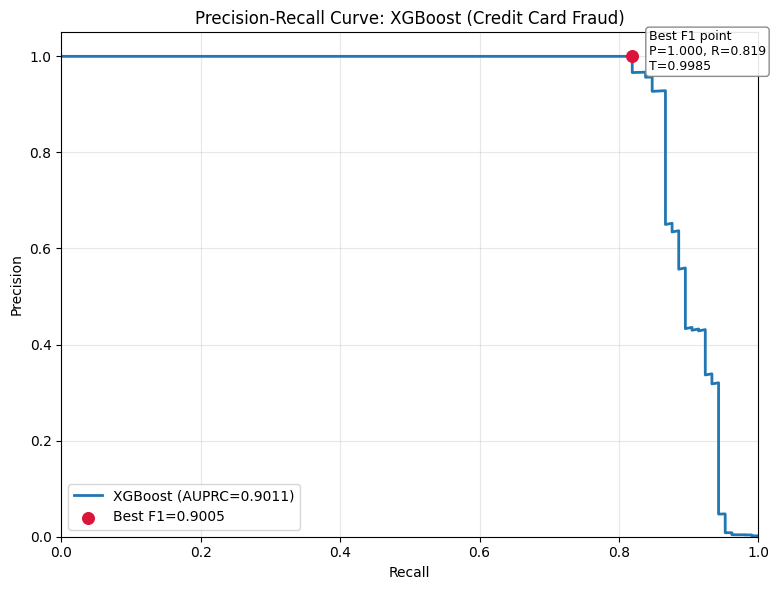

<Figure size 640x480 with 0 Axes>

In [72]:
# Plot precision-recall curve for XGBoost on both datasets
# IEEE-CIS dataset
plot_precision_recall_curve(scores_xgb_val, y_val, label="XGBoost", dataset_name="IEEE-CIS")

# Credit Card Fraud dataset
plot_precision_recall_curve(scores_xgb_val_ccf, y_test_ccf, label="XGBoost", dataset_name="Credit Card Fraud")

plt.tight_layout()
plt.show()